# 👤 Stage 8 — Multivariate Statistics, PCA & Experimental Design
## Customer Segmentation + Factorial Experiments — Complete Notebook

---

> 📌 **Tamil:** "Multivariate = ஒரே நேரத்தில் பல variables-ஐ analyze பண்ணுவது.  
> PCA = 100 columns-ஐ 5 important dimensions-ஆக reduce பண்ணுவது.  
> இந்த notebook-ல் customer segmentation + advanced experimental design learn பண்ணுவோம்."

---

### 5 Projects in this Notebook

| # | Project | Concepts | Business Question |
|---|---------|---------|-------------------|
| 1 | CRM Customer Dataset | Data generation + EDA | Who are our customers?(நம்ம customers எப்படி இருக்கிறார்கள்?) |
| 2 | PCA Deep-Dive | Scree plot, loadings, biplot | Which dimensions matter? |
| 3 | Customer Segmentation | PCA + KMeans + profiling | 4 distinct customer types? |
| 4 | MANOVA | Multivariate group comparison | Do segments differ simultaneously? |
| 5 | Two-Way ANOVA + Interaction | Factorial experiment design | Price × Channel interaction? |

---

Multivariate : 

| Customer | Age | Salary | Spending | Visits |
| -------- | --- | ------ | -------- | ------ |
| A        | 25  | 30k    | 10k      | 5      |
| B        | 40  | 80k    | 25k      | 12     |


இங்கே Age மட்டும் பார்த்தால் போதாது.

நாம் பார்க்க வேண்டியது: 
வயது,
சம்பளம்,
செலவு,
கடைக்கு வரும் எண்ணிக்கை 
அனைத்தையும் சேர்த்து Analyze செய்வது = Multivariate Statistics

------------------------------------------------

Scree Plot - Question: "எத்தனை PCA Components வைத்துக்கொள்ள வேண்டும்?

| Component | Importance |
| --------- | ---------- |
| PC1       | 50%        |
| PC2       | 25%        |
| PC3       | 15%        |
| PC4       | 5%         |
| PC5       | 3%         |

முதல் 3 components: 50 + 25 + 15 = 90% Information கொண்டிருக்கிறது. அதனால் PC1, PC2, PC3 போதும்.

----------------------------------------------------

---

CRM customers

| Customer | Age | Income | Spending |
| -------- | --- | ------ | -------- |
| Ravi     | 22  | Low    | High     |
| Priya    | 40  | High   | Medium   |
| Kumar    | 55  | High   | Low      |

இதிலிருந்து கண்டுபிடிக்கலாம்:
Young Customers,
Rich Customers,
Frequent Buyers,
Premium Customers

---

PCA - என்ன செய்கிறது?

100 Columns → 5 Important Columns

School Example
 ஒரு மாணவரின்: 
Maths,
Physics,
Chemistry,
மூன்றும் ஒரே விஷயத்தை சொல்லலாம்: "Science Ability"  PCA இதை கண்டுபிடிக்கும்.

---

1000 Customers

↓

4 Groups

Segment 1 - Budget Customers: 
Low Income,
Low Spending

Segment 2 - Premium Customers:
High Income, 
High Spending

Segment 3 - Loyal Customers: 
Frequent Visits
Segment 4 - New Customers :
Recently Joined

இதையே Customer Segmentation என்று சொல்வார்கள்.

KMeans Computer தானாக "இந்த customer இந்த group" என்று பிரிக்கும் Algorithm.

---

MANOVA - Business Question: "Do segments differ?"

ANOVA - ஒரு variable மட்டும் பார்க்கும். Example : Spending மட்டும்.

MANOVA: பல variables பார்க்கும்.

Example

Compare: Segment A vs Segment B

Using:

Income,
Spending,
Visits மூன்றையும் ஒரே நேரத்தில்.

School Example

Class A vs Class B

Compare:

Maths , Science, English ஒரே test-ல். இதுதான் MANOVA.

Result

p-value < 0.05

↓

Groups Different

p-value > 0.05

↓

Groups Similar

---

Two-Way ANOVA - Business Question : "Price × Channel affect sales?"

Factor 1 - Price

Low, High

Factor 2 - Channel

Online, Offline Sales Measure செய்கிறோம்.

Main Effect: 

Price Effect

Low Price

↓

More Sales?

Channel Effect

Online

↓

More Sales?

Interaction Effect இதுதான் முக்கியம்.

| Price | Online | Offline |
| ----- | ------ | ------- |
| Low   | 100    | 50      |
| High  | 80     | 75      |


Online-ல் Price Change பெரிய Impact

Offline-ல் Price Change குறைவான Impact

அதாவது Price Effect depends on Channel இதுதான் Interaction Effect

---

| Project            | Simple Meaning                                         |
| ------------------ | ------------------------------------------------------ |
| CRM Dataset        | Customers-ஐ புரிந்துகொள்வது                            |
| PCA                | 100 columns → 5 important dimensions                   |
| Scree Plot         | எத்தனை PCA components வேண்டும்?                        |
| Loadings           | Component-ஐ உருவாக்கிய variables                       |
| Biplot             | Customers + Variables visualization                    |
| Segmentation       | Customers-ஐ குழுக்களாக பிரித்தல்                       |
| KMeans             | Automatic grouping algorithm                           |
| MANOVA             | பல variables-ஐ ஒரே நேரத்தில் compare செய்தல்           |
| Two-Way ANOVA      | 2 factors sales-ஐ பாதிக்கிறதா?                         |
| Interaction Effect | ஒரு factor-ன் effect மற்ற factor-ஐ பொறுத்து மாறுகிறதா? |


## ⚙️ Step 0 — Imports

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import f as f_dist
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.multivariate.manova import MANOVA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PURPLE='#534AB7'; TEAL='#0F6E56'; AMBER='#BA7517'
CORAL='#993C1D'; BLUE='#185FA5'; DGRAY='#5F5E5A'; GREEN='#3B6D11'
SEG_COLORS = [PURPLE, TEAL, AMBER, CORAL, BLUE, GREEN]

plt.rcParams.update({
    'figure.facecolor':'#FAFAFA','axes.facecolor':'#FFFFFF',
    'axes.grid':True,'grid.alpha':0.25,'grid.linestyle':'--',
    'font.family':'DejaVu Sans',
    'axes.spines.top':False,'axes.spines.right':False,
})
print("All imports ready!")


All imports ready!


---
---
# 🗄️ Project 1 — Generate Realistic CRM Dataset (50 Features)

> 📌 **Tamil:** "50 customer attributes — age, income, purchase history, browsing behaviour, demographics.  
> PCA இல்லாமல் இந்த data-ஐ visualize பண்ண முடியாது!"

### Why we need PCA here
50 features = 50 dimensions. Humans can visualise 2-3 dimensions.  
PCA compresses 50 → 2-5 dimensions while **retaining maximum variance**. "50 customer attributes-ஐ சில முக்கிய dimensions-ஆக சுருக்கி, முக்கிய தகவலை (variance) பாதுகாப்பது PCA-வின் வேலை." 🚀

---

❓ பிரச்சனை என்ன? : 
50 Features = 50 Dimensions
மனிதர்களால் 2D அல்லது 3D மட்டுமே எளிதாக பார்க்க முடியும்
50 Dimensions-ஐ Graph-ல் நேரடியாக காட்ட முடியாது

In [2]:
np.random.seed(42)
n = 1500   # customers

# ── Core demographics ─────────────────────────────────────────
age          = np.random.normal(38, 12, n).clip(18, 75).round(0)
income_lpa   = np.random.lognormal(3.2, 0.55, n).round(2)
city_tier    = np.random.choice([1,2,3], n, p=[0.35,0.40,0.25])

# ── Purchase behaviour (correlated with income) ───────────────
spend_score   = (0.4*income_lpa/income_lpa.max()*100 +
                 0.3*np.random.normal(50,20,n) +
                 0.3*np.random.normal(50,15,n)).clip(1,100).round(1)
frequency_pm  = (2 + 0.04*income_lpa + np.random.normal(0,2,n)).clip(0.5,25).round(1)
avg_order_val = (income_lpa*0.15 + np.random.normal(0,500,n)).clip(200,15000).round(0)
recency_days  = np.random.exponential(45, n).clip(1,365).round(0)
total_orders  = (frequency_pm * np.random.uniform(8,14,n)).round(0)
total_spend   = (avg_order_val * total_orders).round(0)
clv           = (total_spend * np.random.uniform(1.5,3.5,n)).round(0)

# ── Product category preferences ─────────────────────────────
cat_electronics = np.random.beta(2,5,n).round(3)
cat_fashion     = np.random.beta(3,4,n).round(3)
cat_grocery     = np.random.beta(4,3,n).round(3)
cat_beauty      = np.random.beta(2,6,n).round(3)
cat_sports      = np.random.beta(1.5,5,n).round(3)
cat_home        = np.random.beta(2,4,n).round(3)

# ── Engagement behaviour ──────────────────────────────────────
app_sessions_pw  = (1 + income_lpa*0.02 + np.random.normal(0,2,n)).clip(0,30).round(1)
email_open_rate  = np.random.beta(3,5,n).round(3)
push_click_rate  = np.random.beta(2,6,n).round(3)
web_sessions_pw  = (app_sessions_pw * np.random.uniform(0.5,2,n)).round(1)
pages_per_session= np.random.exponential(4,n).clip(1,20).round(1)
cart_abandon_rate= np.random.beta(4,3,n).round(3)
wishlist_items   = np.random.poisson(3,n)
reviews_written  = np.random.poisson(2,n)
returns_rate     = np.random.beta(2,8,n).round(3)
referrals_made   = np.random.poisson(1,n)

# ── Channel preferences ───────────────────────────────────────
pref_mobile  = np.random.beta(3,2,n).round(3)
pref_desktop = 1 - pref_mobile
pref_app     = np.random.beta(2,3,n).round(3)

# ── Loyalty & satisfaction ────────────────────────────────────
loyalty_years  = np.random.exponential(2.5,n).clip(0,12).round(1)
nps_score      = np.random.choice(range(0,11),n,
                                   p=[.03,.02,.03,.04,.05,.08,.10,.15,.18,.18,.14])
satisfaction   = np.random.choice([1,2,3,4,5],n,p=[.04,.07,.15,.40,.34])
support_tickets= np.random.poisson(1.2,n)
discount_usage = np.random.beta(3,4,n).round(3)

# ── Derived / composite features ─────────────────────────────
engagement_score = (0.3*app_sessions_pw/app_sessions_pw.max()*100 +
                    0.3*email_open_rate*100 +
                    0.4*spend_score).round(1)
churn_risk = (0.4*(recency_days/365) +
              0.3*(1-email_open_rate) +
              0.3*(1-frequency_pm/frequency_pm.max())).round(3)

df_crm = pd.DataFrame({
    'customer_id'       : [f'C{i:05d}' for i in range(1,n+1)],
    'age'               : age.astype(int),
    'income_lpa'        : income_lpa,
    'city_tier'         : city_tier,
    'spend_score'       : spend_score,
    'frequency_pm'      : frequency_pm,
    'avg_order_val'     : avg_order_val.astype(int),
    'recency_days'      : recency_days.astype(int),
    'total_orders'      : total_orders.astype(int),
    'total_spend'       : total_spend.astype(int),
    'clv'               : clv.astype(int),
    'cat_electronics'   : cat_electronics,
    'cat_fashion'       : cat_fashion,
    'cat_grocery'       : cat_grocery,
    'cat_beauty'        : cat_beauty,
    'cat_sports'        : cat_sports,
    'cat_home'          : cat_home,
    'app_sessions_pw'   : app_sessions_pw,
    'email_open_rate'   : email_open_rate,
    'push_click_rate'   : push_click_rate,
    'web_sessions_pw'   : web_sessions_pw,
    'pages_per_session' : pages_per_session,
    'cart_abandon_rate' : cart_abandon_rate,
    'wishlist_items'    : wishlist_items,
    'reviews_written'   : reviews_written,
    'returns_rate'      : returns_rate,
    'referrals_made'    : referrals_made,
    'pref_mobile'       : pref_mobile,
    'pref_desktop'      : pref_desktop,
    'pref_app'          : pref_app,
    'loyalty_years'     : loyalty_years,
    'nps_score'         : nps_score,
    'satisfaction'      : satisfaction,
    'support_tickets'   : support_tickets,
    'discount_usage'    : discount_usage,
    'engagement_score'  : engagement_score,
    'churn_risk'        : churn_risk,
})

df_crm.to_csv('crm_customers.csv', index=False)
print(f"Dataset saved: crm_customers.csv")
print(f"  {len(df_crm):,} customers  x  {df_crm.shape[1]} columns (37 total incl. ID)")
print(f"  Numeric features: {df_crm.select_dtypes(include=np.number).shape[1]}")
print()
print(df_crm.describe().round(2).T[['mean','std','min','max']].to_string())

# | Column        | Meaning (English)            | தமிழ் விளக்கம்                                               |
# | ------------- | ---------------------------- | ------------------------------------------------------------ |
# | customer_id   | Customer ID                  | ஒவ்வொரு Customer-க்கும் தனிப்பட்ட அடையாள எண்                 |
# | age           | Age                          | வாடிக்கையாளர் வயது                                           |
# | income_lpa    | Income (Lakhs Per Annum)     | வருட வருமானம் (லட்சங்களில்)                                  |
# | city_tier     | City Category                | Tier 1 = பெரிய நகரம், Tier 2 = நடுத்தர, Tier 3 = சிறிய நகரம் |
# | spend_score   | Spending Score               | Customer எவ்வளவு செலவு செய்கிறார் (1–100)                    |
# | frequency_pm  | Purchase Frequency Per Month | மாதத்திற்கு எத்தனை முறை வாங்குகிறார்                         |
# | avg_order_val | Average Order Value          | ஒரு Order-க்கு சராசரி செலவு                                  |
# | recency_days  | Days Since Last Purchase     | கடைசியாக வாங்கியதிலிருந்து கடந்த நாட்கள்                     |
# | total_orders  | Total Orders                 | மொத்த ஆர்டர்கள்                                              |
# | total_spend   | Total Spending               | மொத்தமாக செலவு செய்த தொகை                                    |
# | clv           | Customer Lifetime Value      | Customer வாழ்நாளில் தரும் மொத்த மதிப்பு                      |

# | Column          | தமிழ் விளக்கம்                            |
# | --------------- | ----------------------------------------- |
# | cat_electronics | Electronics பொருட்கள் மீது விருப்பம்      |
# | cat_fashion     | Fashion பொருட்கள் மீது விருப்பம்          |
# | cat_grocery     | Grocery பொருட்கள் மீது விருப்பம்          |
# | cat_beauty      | Beauty பொருட்கள் மீது விருப்பம்           |
# | cat_sports      | Sports பொருட்கள் மீது விருப்பம்           |
# | cat_home        | Home & Furniture பொருட்கள் மீது விருப்பம் |👉 0 = விருப்பம் இல்லை 👉 1 = மிக அதிக விருப்பம்

# | Column            | தமிழ் விளக்கம்                           |
# | ----------------- | ---------------------------------------- |
# | app_sessions_pw   | வாரத்திற்கு App திறக்கும் முறை           |
# | email_open_rate   | Email திறக்கும் விகிதம்                  |
# | push_click_rate   | Push Notification Click Rate             |
# | web_sessions_pw   | Website பயன்படுத்தும் முறை (வாரத்திற்கு) |
# | pages_per_session | ஒரு Session-ல் பார்க்கும் Pages          |
# | cart_abandon_rate | Cart-ல் சேர்த்து வாங்காமல் விட்ட விகிதம் |
# | wishlist_items    | Wishlist-ல் உள்ள பொருட்கள்               |
# | reviews_written   | எழுதிய Reviews எண்ணிக்கை                 |
# | returns_rate      | வாங்கியதை Return செய்த விகிதம்           |
# | referrals_made    | நண்பர்களை Refer செய்த எண்ணிக்கை          |

# | Column       | தமிழ் விளக்கம்                          | 💻 Channel Preference Features
# | ------------ | --------------------------------------- |
# | pref_mobile  | Mobile மூலம் வாங்கும் விருப்பம்         |
# | pref_desktop | Desktop/Laptop மூலம் வாங்கும் விருப்பம் |
# | pref_app     | Mobile App மூலம் வாங்கும் விருப்பம்     | 👉 0 = குறைந்த விருப்பம் 👉 1 = அதிக விருப்பம்

# | Column          | தமிழ் விளக்கம்                           |
# | --------------- | ---------------------------------------- |
# | loyalty_years   | எத்தனை ஆண்டுகளாக Customer ஆக இருக்கிறார் |
# | nps_score       | Net Promoter Score (0–10)                |
# | satisfaction    | Customer Satisfaction Rating (1–5)       |
# | support_tickets | Customer Support Complaints எண்ணிக்கை    |
# | discount_usage  | Discount Coupons பயன்படுத்தும் அளவு      |

# | Column           | Formula Idea                | தமிழ் விளக்கம்                  |
# | ---------------- | --------------------------- | ------------------------------- |
# | engagement_score | App + Email + Spending      | Customer Engagement Score       |
# | churn_risk       | Recency + Email + Frequency | Customer விட்டு செல்லும் அபாயம் |


Dataset saved: crm_customers.csv
  1,500 customers  x  37 columns (37 total incl. ID)
  Numeric features: 36

                       mean       std      min        max
age                   38.76     11.51    18.00      75.00
income_lpa            28.67     17.25     4.66     212.60
city_tier              1.88      0.76     1.00       3.00
spend_score           34.99      8.13     9.50      64.00
frequency_pm           3.30      2.02     0.50      11.80
avg_order_val        306.51    207.37   200.00    1584.00
recency_days          45.64     46.73     1.00     304.00
total_orders          36.25     23.00     4.00     159.00
total_spend        11097.10  11067.22   800.00   97230.00
clv                28024.34  29474.91  1200.00  333417.00
cat_electronics        0.28      0.16     0.00       0.83
cat_fashion            0.43      0.17     0.01       0.92
cat_grocery            0.57      0.17     0.11       0.96
cat_beauty             0.25      0.14     0.01       0.76
cat_sports          

---
---
# 🔍 Project 2 — PCA Deep-Dive
## Scree Plot + Loadings + Biplot

---

> 📌 **Tamil:** "PCA steps:  
> 1. Standardize (mean=0, std=1) - Data Standardize செய்ய வேண்டும்
> 2. Covariance matrix calculate -Covariance Matrix உருவாக்க வேண்டும்
> 3. Eigenvectors (directions) and eigenvalues (variance explained) find - Eigenvalues & Eigenvectors கண்டுபிடிக்க வேண்டும்
> 4. Top components select  - முக்கிய Components தேர்வு செய்ய வேண்டும்
> 5. Project data onto new axes" - Data-ஐ புதிய Axes-க்கு மாற்ற வேண்டும்

### Key Concepts
| Term | Meaning |
|------|---------|
| **Principal Component** | New axis that captures maximum variance |
| **Eigenvalue** | Variance explained by each component |
| **Explained variance ratio** | % of total variance per component |
| **Loading** | Correlation between original feature and PC |
| **Scree plot** | Elbow method to choose n_components |


---

1️⃣ Principal Component (PC) : Original Features-ல உள்ள தகவலை அதிகமாக வைத்திருக்கும் புதிய Axis.

Rule: 

> PC1 = அதிக Variance, 
> PC2 = அடுத்த அதிக Variance, 
> PC3 = அதற்கு அடுத்தது

---

2️⃣ Eigenvalue : ஒரு Component எவ்வளவு தகவலை (Variance) வைத்திருக்கிறது.

Rule

Eigenvalue அதிகம்

↓

Component முக்கியம்

| Component | Eigenvalue |
| --------- | ---------- |
| PC1       | 5.8        |
| PC2       | 2.4        |
| PC3       | 0.6        |

PC1 அதிக தகவல் வைத்திருக்கிறது.

PC3 மிகக் குறைவான தகவல் வைத்திருக்கிறது.

Quick Rule

Eigenvalue > 1 ✅ Useful

Eigenvalue < 1

❌ Often ignored (Kaiser Rule)

---

3️⃣ Explained Variance Ratio: மொத்த தகவலில் ஒரு Component எவ்வளவு % தகவல் வைத்திருக்கிறது.

Formula : Component Variance ÷ Total Variance

| Component | Variance % |
| --------- | ---------- |
| PC1       | 45%        |
| PC2       | 25%        |
| PC3       | 15%        |

PC1

↓

45% தகவலை வைத்திருக்கிறது.

Cumulative Variance => 45 + 25 + 15 = 85%

Rule : 80%-95% வரை Variance வந்தால் போதும்.

---

4️⃣ Loading : Original Feature ஒரு Component-க்கு எவ்வளவு Contribution கொடுக்கிறது.

PC1

| Feature  | Loading |
| -------- | ------- |
| Income   | 0.90    |
| Spending | 0.85    |
| Orders   | 0.20    |

Income

↓

PC1-ஐ அதிகமாக உருவாக்குகிறது.

Orders

↓

குறைவாக தாக்கம் செய்கிறது.

Rule:

| Loading Value  | Meaning  |
| -------------- | -------- |
| ±0.70 to ±1    | Strong   |
| ±0.40 to ±0.70 | Moderate |
| 0 to ±0.40     | Weak     |

---

5️⃣ Scree Plot: எத்தனை Components வைத்துக்கொள்ள வேண்டும் என்பதை தீர்மானிக்கும் Chart.

X-Axis - Components - PC1, PC2, PC3 ...

Y-Axis - Eigenvalue அல்லது Explained Variance

| PC  | Variance |
| --- | -------- |
| PC1 | 45%      |
| PC2 | 25%      |
| PC3 | 15%      |
| PC4 | 5%       |
| PC5 | 3%       |

> PC1 → பெரிய Contribution
> PC2 → பெரிய Contribution
> PC3 → நல்ல Contribution
> PC4 → மிகக் குறைவு
> PC5 → மிகவும் குறைவு

Rule (Elbow Method) : Chart-ல் வளைவு (Elbow) வரும் இடம் வரை Components எடுக்க வேண்டும்.

Variance
|
| *
|   *
|      *
|         *
|           *
+----------------
 PC1 PC2 PC3 PC4

Elbow = PC3 அதனால் ✅ Keep PC1, PC2, PC3

In [4]:
# 👉 PCA செய்யும் முன் எல்லா Features-ஐ ஒரே Scale-க்கு கொண்டு வருவது
# Select numeric features for PCA (drop ID)
feature_cols = [c for c in df_crm.columns if c != 'customer_id' and
                df_crm[c].dtype in [np.float64, np.int64, float, int]] # customer_id-ஐ remove செய்கிறது.

X_raw = df_crm[feature_cols].values
# | age | income | spend |
# | --- | ------ | ----- |
# | 25  | 15     | 60    |
# | 40  | 30     | 80    |
# NumPy Matrix
# [
#  [25,15,60],
#  [40,30,80]
# ]

# Step 1: Standardize
scaler = StandardScaler() # StandardScaler Object உருவாக்குகிறது. இது Mean, Standard Deviation கணக்கிடும்.
X_scaled = scaler.fit_transform(X_raw)

print(f"Features going into PCA: {len(feature_cols)}") # PCA-க்கு 32 Numeric Features அனுப்பப்பட்டுள்ளன. ✅ PCA 32 Variables-ஐ Analyze செய்யப் போகிறது.
print()
print("Before scaling:") # 32 Features-ல் - சிறிய Mean = 0.2 , பெரிய Mean = 28024.3
# | Feature         | Std      |
# | --------------- | -------- |
# | email_open_rate | 0.08     |
# | total_spend     | 29465.09 |
print(f"  Mean range  : {X_raw.mean(axis=0).min():.1f} to {X_raw.mean(axis=0).max():.1f}")
print(f"  Std range   : {X_raw.std(axis=0).min():.2f} to {X_raw.std(axis=0).max():.2f}")
print()
print("After scaling:") # Scaling பிறகு ஒவ்வொரு Feature-ன் Mean ≈ 0 ஆக மாற்றப்பட்டுள்ளது. அனைத்து Features-மும் ஒரே Center-க்கு கொண்டுவரப்பட்டுள்ளன.
print(f"  All means   : {X_scaled.mean(axis=0).mean():.6f} (should be ~0)")
print(f"  All stds    : {X_scaled.std(axis=0).mean():.6f} (should be ~1)")
print()
print("Why standardize?")
print("  income_lpa (range 5-50) would dominate recency_days (range 1-365)")
print("  without scaling — PCA would just capture variance of the biggest-range feature!")

# income_lpa (5–50 range) மற்றும் recency_days (1–365 range) ஆகியவற்றின் அளவுகள் (scale) வேறுபடுகின்றன.
# Standardization செய்யாமல் விட்டால், பெரிய range கொண்ட feature-ன் variance அதிகமாக இருக்கும்.
# அதனால் PCA, அந்த feature-க்கு மட்டும் அதிக முக்கியத்துவம் கொடுக்கும்.
# இதன் விளைவாக, மற்ற முக்கியமான features-ன் தாக்கம் குறைந்து விடும்.

Features going into PCA: 32

Before scaling:
  Mean range  : 0.2 to 28024.3
  Std range   : 0.08 to 29465.09

After scaling:
  All means   : 0.000000 (should be ~0)
  All stds    : 1.000000 (should be ~1)

Why standardize?
  income_lpa (range 5-50) would dominate recency_days (range 1-365)
  without scaling — PCA would just capture variance of the biggest-range feature!


In [5]:
# 👉 32 Features-ல் எவ்வளவு தகவலை ஒவ்வொரு Principal Component (PC) வைத்திருக்கிறது? என்பதை கண்டுபிடிக்கிறது.
# Step 2: Fit PCA with ALL components first (to see full picture)
pca_full = PCA(n_components=len(feature_cols)) # 32 Features இருந்தால் PC1 PC2 PC3 ... PC32 அனைத்து Components-ஐ உருவாக்கு.
pca_full.fit(X_scaled) # Scaled Data-க்கு PCA Apply செய்கிறது. PCA கண்டுபிடிக்கும்: Eigenvalues, Eigenvectors ,Variance Explained

evr   = pca_full.explained_variance_ratio_ # ஒவ்வொரு PC எவ்வளவு Variance (Information) வைத்திருக்கிறது.
cumevr= np.cumsum(evr) # Cumulative Variance அதாவது PC1 + PC2 + PC3 ... மொத்த தகவல்.

print("EXPLAINED VARIANCE BY COMPONENT")
print("="*55)
print(f"{'PC':<6} {'Eigenvalue':>12} {'Var Expl %':>12} {'Cumulative %':>14}")
print("-"*46)
for i, (ev, var, cumvar) in enumerate(zip(pca_full.explained_variance_,
                                           evr*100, cumevr*100)):
    marker = ' <-- elbow' if i==3 else (' <-- 80%' if cumvar>=80 and (i==0 or cumevr[i-1]*100<80) else '')
    print(f"PC{i+1:<4}  {ev:>12.4f}  {var:>11.2f}%  {cumvar:>13.2f}%{marker}")
    if i >= 14: print("  ..."); break

print()
n_80pct = np.argmax(cumevr >= 0.80) + 1
n_90pct = np.argmax(cumevr >= 0.90) + 1
print(f"  Components for 80% variance: {n_80pct}  (from {len(feature_cols)} original features)")
print(f"  Components for 90% variance: {n_90pct}")
print(f"  Compression ratio (80% threshold): {len(feature_cols)}/{n_80pct} = {len(feature_cols)/n_80pct:.1f}x")

# | PC                                | Eigenvalue (என்ன?) | Var Expl % (என்ன?) | Cumulative % (என்ன?) | Interpretation (தமிழ்)                                                                                                                     |
# | --------------------------------- | ------------------ | ------------------ | -------------------- | ------------------------------------------------------------------------------------------------------------------------------------------ |
# | **PC1**                           | **3.8931**         | **12.16%**         | **12.16%**           | PC1 மிகவும் முக்கியமான Component. Dataset-ல் உள்ள மொத்த தகவலின் 12.16% இதுவே தனியாக வைத்திருக்கிறது.                                       |
# | **PC4**                           | **1.7918**         | **5.60%**          | **32.35%**           | PC1 முதல் PC4 வரை சேர்த்து 32.35% தகவல் உள்ளது. PC4-ல் Elbow Point வந்துள்ளது; இதற்கு பிறகு ஒவ்வொரு Component-ம் குறைவான தகவல் சேர்க்கும். |
# | **PC15** (கடைசியாக காட்டப்பட்டது) | **0.9815**         | **3.07%**          | **71.45%**           | PC1 முதல் PC15 வரை சேர்த்து 71.45% தகவல் உள்ளது. Eigenvalue 1-க்கு கீழே வந்ததால், இந்த Component முக்கியத்துவம் குறையத் தொடங்குகிறது.      |

# | Column           | தமிழ் அர்த்தம்                                                           | Rule (விதி)                                                                                  |
# | ---------------- | ------------------------------------------------------------------------ | -------------------------------------------------------------------------------------------- |
# | **Eigenvalue**   | அந்த PC எவ்வளவு Variance (தகவல்) வைத்திருக்கிறது என்பதை காட்டும் மதிப்பு | **Eigenvalue > 1** → முக்கியமான Component ✅<br>**Eigenvalue < 1** → முக்கியத்துவம் குறைவு ⚠️ |
# | **Var Expl %**   | அந்த PC மட்டும் விளக்கும் தகவலின் சதவீதம்                                | **அதிக %** → அந்த PC முக்கியம் ✅<br>**குறைந்த %** → தகவல் குறைவு                             |
# | **Cumulative %** | அந்த PC வரை உள்ள அனைத்து PCs சேர்த்து விளக்கும் மொத்த தகவல் சதவீதம்      | **80%–90% வந்தால் போதும்** ✅<br>அதற்கு மேல் Components சேர்ப்பது குறைந்த பயன் தரும்          |

# | Output                                                          | தமிழ் விளக்கம்                                                                                        | Interpretation                                                           |
# | --------------------------------------------------------------- | ----------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------ |
# | **Components for 80% variance: 18 (from 32 original features)** | 32 Original Features-ல் உள்ள மொத்த தகவலின் **80%**-ஐ பாதுகாக்க **18 Principal Components** போதுமானது. | 32 Columns → 18 PCs ஆக குறைத்தாலும் 80% தகவல் இருக்கும். ✅               |
# | **Components for 90% variance: 22**                             | மொத்த தகவலின் **90%**-ஐ பாதுகாக்க **22 Principal Components** தேவை.                                   | அதிக தகவல் வேண்டும் என்றால் அதிக PCs வைத்துக்கொள்ள வேண்டும்.             |
# | **Compression ratio (80% threshold): 32/18 = 1.8x**             | 32 Features-ஐ 18 Components-ஆக சுருக்கியுள்ளோம்.                                                      | Data Size **1.8 மடங்கு குறைந்தது**, ஆனால் 80% தகவல் பாதுகாக்கப்பட்டது. ✅ |


EXPLAINED VARIANCE BY COMPONENT
PC       Eigenvalue   Var Expl %   Cumulative %
----------------------------------------------
PC1           3.8931        12.16%          12.16%
PC2           2.6567         8.30%          20.45%
PC3           2.0188         6.30%          26.76%
PC4           1.7918         5.60%          32.35% <-- elbow
PC5           1.5697         4.90%          37.26%
PC6           1.2151         3.79%          41.05%
PC7           1.1878         3.71%          44.76%
PC8           1.1743         3.67%          48.43%
PC9           1.1237         3.51%          51.94%
PC10          1.0990         3.43%          55.37%
PC11          1.0590         3.31%          58.68%
PC12          1.0515         3.28%          61.96%
PC13          1.0356         3.23%          65.19%
PC14          1.0213         3.19%          68.38%
PC15          0.9815         3.07%          71.45%
  ...

  Components for 80% variance: 18  (from 32 original features)
  Components for 90% varianc

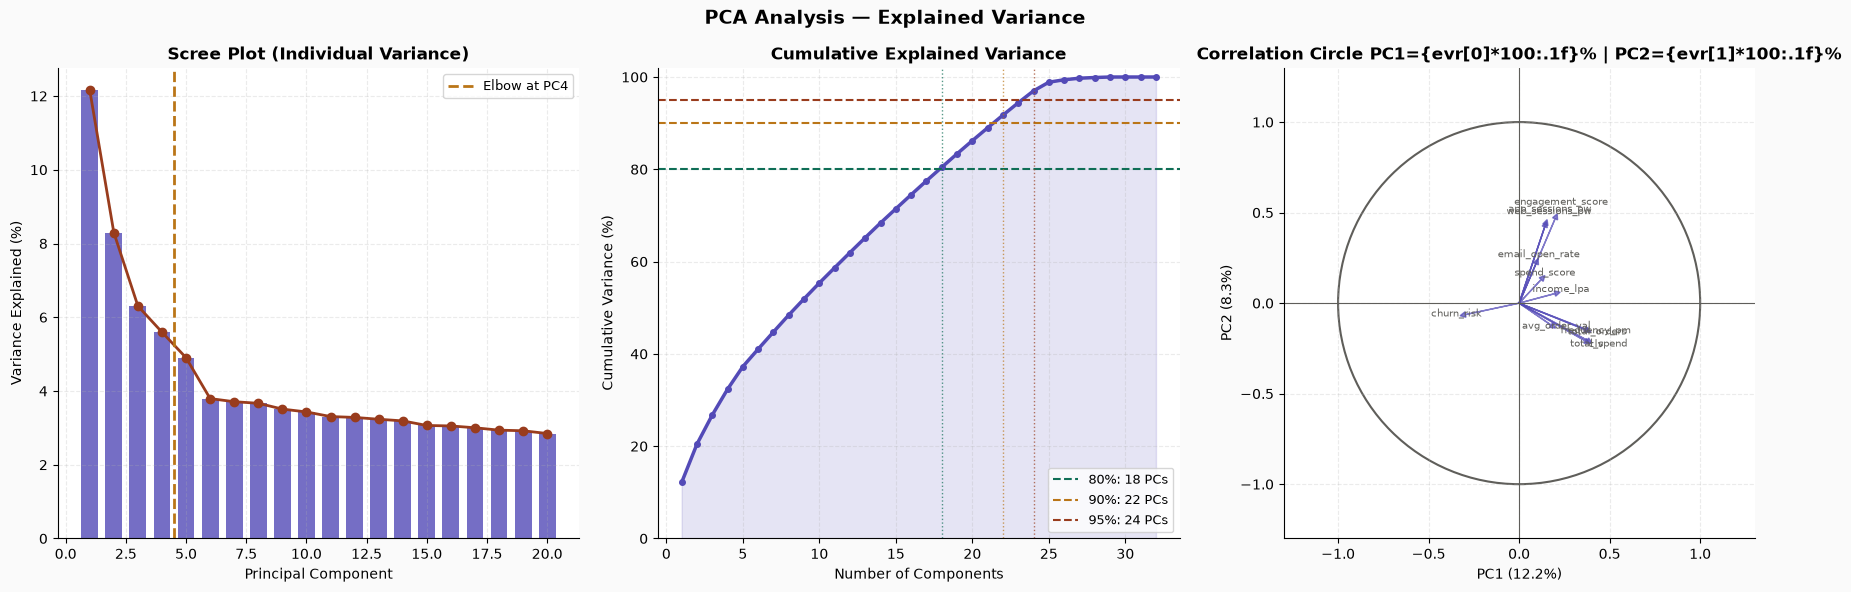

In [6]:
# Scree plot + cumulative variance
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('PCA Analysis — Explained Variance', fontsize=14, fontweight='bold')

# P1: Scree plot -ஒவ்வொரு Principal Component (PC) தனியாக எவ்வளவு தகவல் (Variance) வைத்திருக்கிறது என்பதை காட்டுகிறது.
# | பகுதி                    | விளக்கம்                                   |
# | ------------------------ | ------------------------------------------ |
# | **X-Axis**               | Principal Components (PC1, PC2, PC3...)    |
# | **Y-Axis**               | Variance Explained (%)                     |
# | **Purple Bars**          | ஒவ்வொரு PC தனியாக வைத்திருக்கும் தகவல் (%) |
# | **Orange Line + Dots**   | Variance குறையும் Pattern                  |
# | **Dashed Vertical Line** | Elbow Point (PC4)                          |

# | Observation                      | Interpretation                  |
# | -------------------------------- | ------------------------------- |
# | PC1 Bar உயரம் அதிகம்             | PC1 மிகவும் முக்கியம்           |
# | PC2, PC3 குறைகிறது               | தகவல் குறைகிறது                 |
# | PC4 பிறகு Bars மெதுவாக குறைகிறது | புதிய PCs அதிக தகவல் தரவில்லை   |
# | Elbow at PC4                     | முக்கிய PCs = PC1 முதல் PC4 வரை |

n_show = 20
axes[0].bar(range(1, n_show+1), evr[:n_show]*100, color=PURPLE, alpha=0.8, width=0.7)
axes[0].plot(range(1, n_show+1), evr[:n_show]*100, color=CORAL, linewidth=2,
             marker='o', markersize=6)
axes[0].axvline(4.5, color=AMBER, linewidth=2, linestyle='--', label='Elbow at PC4')
axes[0].set_title('Scree Plot (Individual Variance)', fontweight='bold')
axes[0].set_xlabel('Principal Component'); axes[0].set_ylabel('Variance Explained (%)')
axes[0].legend(fontsize=9)

# P2: Cumulative variance - PCs சேரச் சேர மொத்தமாக எவ்வளவு தகவல் கிடைக்கிறது என்பதை காட்டுகிறது.
# | பகுதி                       | விளக்கம்                     |
# | --------------------------- | ---------------------------- |
# | **X-Axis**                  | Number of Components         |
# | **Y-Axis**                  | Cumulative Variance (%)      |
# | **Purple Line**             | மொத்த தகவல் (%) அதிகரிப்பு   |
# | **Purple Shade**            | இதுவரை சேமிக்கப்பட்ட தகவல்   |
# | **Horizontal Dashed Lines** | 80%, 90%, 95% Targets        |
# | **Vertical Dotted Lines**   | அந்த Target அடைய வேண்டிய PCs |

# | Point  | Meaning              |
# | ------ | -------------------- |
# | 18 PCs | 80% தகவல் கிடைக்கும் |
# | 22 PCs | 90% தகவல் கிடைக்கும் |
# | 24 PCs | 95% தகவல் கிடைக்கும் |
# Purple Line ஏன் மேலே செல்கிறது?
# PC1 தகவல் ➕ PC2 தகவல் ➕ PC3 தகவல்... சேர்ந்து கொண்டே போகிறது. அதனால் Line எப்போதும் மேலே போகும்.

axes[1].plot(range(1, len(evr)+1), cumevr*100, color=PURPLE, linewidth=2.5,
             marker='o', markersize=4)
axes[1].fill_between(range(1, len(evr)+1), cumevr*100, alpha=0.15, color=PURPLE)
for pct, col in [(80,TEAL),(90,AMBER),(95,CORAL)]:
    n_c = np.argmax(cumevr>=pct/100)+1
    axes[1].axhline(pct, color=col, linewidth=1.5, linestyle='--', label=f'{pct}%: {n_c} PCs')
    axes[1].axvline(n_c, color=col, linewidth=1, linestyle=':', alpha=0.7)
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Components'); axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend(fontsize=9); axes[1].set_ylim(0,102)

# P3: Correlation circle (loadings for PC1 vs PC2) -Features மற்றும் PCs இடையேயான தொடர்பு.
# | Axis   | Meaning     |
# | ------ | ----------- |
# | X-Axis | PC1 (12.2%) |
# | Y-Axis | PC2 (8.3%)  |

# | Part         | Meaning                      |
# | ------------ | ---------------------------- |
# | Big Circle   | Maximum Correlation Boundary |
# | Center (0,0) | Correlation இல்லை            |
# | Circle Edge  | Strong Correlation           |

# | Length      | Meaning                  | ஒவ்வொரு Arrow = ஒரு Feature
# | ----------- | ------------------------ |
# | Long Arrow  | Feature முக்கியம்        |
# | Short Arrow | Feature முக்கியம் குறைவு | 
# engagement_score - Arrow நீளமாக உள்ளது.
# ↓
# PC1 & PC2-க்கு நல்ல Contribution.

# | Arrow Direction                | Example                           | Correlation Type                | தமிழ் விளக்கம்                               | Interpretation                                     |
# | ------------------------------ | --------------------------------- | ------------------------------- | -------------------------------------------- | -------------------------------------------------- |
# | ➡️ ➡️ **Same Direction**       | income_lpa →<br>total_spend →     | **Positive Correlation (+)**    | இரண்டு Arrow-களும் ஒரே திசையில் செல்கின்றன   | Income அதிகரித்தால் Total Spend-மும் அதிகரிக்கும்  |
# | ⬅️ ➡️ **Opposite Direction**   | income_lpa →<br>← churn_risk      | **Negative Correlation (-)**    | இரண்டு Arrow-களும் எதிர் திசையில் செல்கின்றன | Income அதிகரித்தால் Churn Risk குறையும்            |
# | ↗️ ↗️ **Very Close Direction** | spend_score ↗️<br>frequency_pm ↗️ | **Strong Positive Correlation** | Arrow-கள் மிகவும் அருகில் உள்ளன              | ஒரு Feature அதிகரித்தால் மற்றதும் அதிகரிக்கும்     |
# | ↗️ ↘️ **90° (Perpendicular)**  | income ↗️<br>email_open_rate ↘️   | **No / Weak Correlation**       | Arrow-கள் சுமார் 90° கோணத்தில் உள்ளன         | இரண்டு Features-க்கும் தொடர்பு குறைவு அல்லது இல்லை |

# | Quadrant               | Direction | Meaning                    |
# | ---------------------- | --------- | -------------------------- |
# | **Top Right (+,+)**    | ↗️        | PC1 Positive, PC2 Positive |
# | **Top Left (-,+)**     | ↖️        | PC1 Negative, PC2 Positive |
# | **Bottom Left (-,-)**  | ↙️        | PC1 Negative, PC2 Negative |
# | **Bottom Right (+,-)** | ↘️        | PC1 Positive, PC2 Negative |

#         PC2 (+)
#            ↑
#     ↖️      |      ↗️
#    (-,+)   |    (+,+)
# ------------+------------→ PC1 (+)
#     ↙️      |      ↘️
#    (-,-)   |    (+,-)
#            ↓
#         PC2 (-)

pca_2 = PCA(n_components=2)
X_pca2 = pca_2.fit_transform(X_scaled)
loadings = pca_2.components_.T

axes[2].axhline(0, color=DGRAY, linewidth=0.8)
axes[2].axvline(0, color=DGRAY, linewidth=0.8)
circle = plt.Circle((0,0), 1, fill=False, color=DGRAY, linewidth=1.5)
axes[2].add_patch(circle)

# Show top 12 features by loading magnitude
top_feat_idx = np.argsort(np.sqrt(loadings[:,0]**2 + loadings[:,1]**2))[-12:]
for i in top_feat_idx:
    axes[2].arrow(0, 0, loadings[i,0]*0.9, loadings[i,1]*0.9,
                  head_width=0.03, head_length=0.03, color=PURPLE, alpha=0.7)
    axes[2].text(loadings[i,0]*1.05, loadings[i,1]*1.05,
                 feature_cols[i], fontsize=7, ha='center', color=DGRAY)

axes[2].set_xlim(-1.3,1.3); axes[2].set_ylim(-1.3,1.3)
axes[2].set_title('Correlation Circle PC1={evr[0]*100:.1f}% | PC2={evr[1]*100:.1f}%',
                   fontweight='bold')
axes[2].set_xlabel(f'PC1 ({evr[0]*100:.1f}%)'); axes[2].set_ylabel(f'PC2 ({evr[1]*100:.1f}%)')
axes[2].set_aspect('equal')

plt.tight_layout()
plt.savefig('p2_pca_variance.png', dpi=130, bbox_inches='tight')
plt.show()


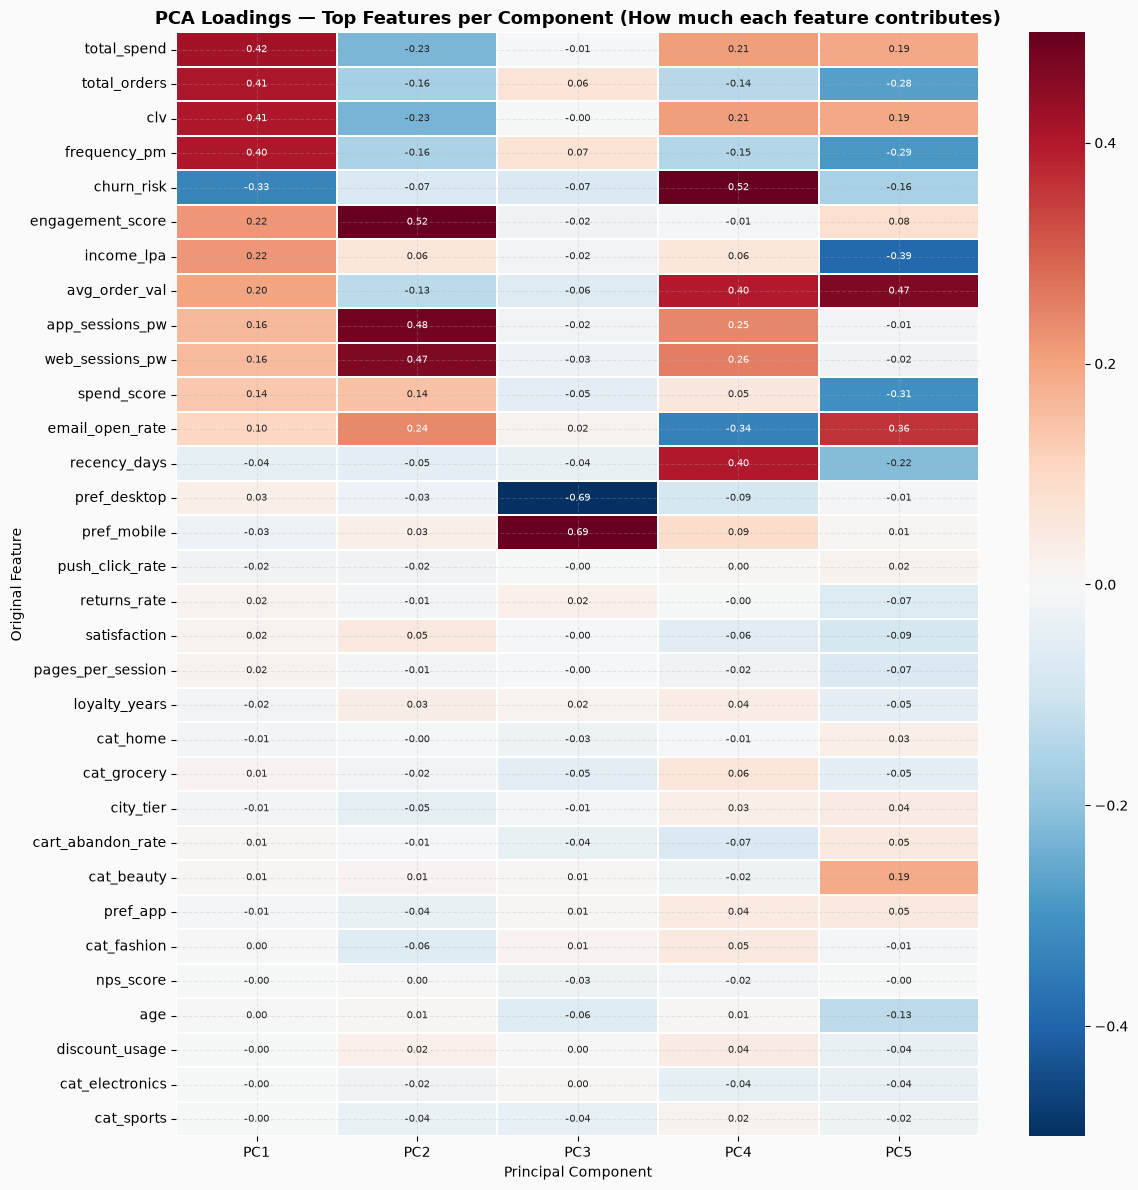

PC INTERPRETATION (from loadings):

  PC1 (12.2% variance):
    Positive: ['total_spend', 'total_orders', 'clv']
    Negative: ['churn_risk', 'recency_days', 'pref_mobile']

  PC2 (8.3% variance):
    Positive: ['engagement_score', 'app_sessions_pw', 'web_sessions_pw']
    Negative: ['clv', 'total_spend', 'total_orders']

  PC3 (6.3% variance):
    Positive: ['pref_mobile', 'frequency_pm', 'total_orders']
    Negative: ['pref_desktop', 'churn_risk', 'avg_order_val']

  PC4 (5.6% variance):
    Positive: ['churn_risk', 'recency_days', 'avg_order_val']
    Negative: ['email_open_rate', 'frequency_pm', 'total_orders']

  PC5 (4.9% variance):
    Positive: ['avg_order_val', 'email_open_rate', 'clv']
    Negative: ['income_lpa', 'spend_score', 'frequency_pm']



In [7]:
# Feature loadings heatmap — which original features drive each PC?
# 👉 ஒவ்வொரு Principal Component (PC1, PC2, PC3...) உருவாக எந்த Features அதிகமாக பங்களித்தன?
# என்பதை கண்டுபிடிக்கிறது. இதையே Loadings என்று சொல்வார்கள்.
pca_5 = PCA(n_components=5) # முதல் 5 PCs மட்டும் எடுக்கிறது.
pca_5.fit(X_scaled) # Scaled Data மீது PCA Run செய்கிறது.
loadings_5 = pd.DataFrame(pca_5.components_.T, 
                           index=feature_cols,
                           columns=[f'PC{i+1}' for i in range(5)])

# | Loading Value | Meaning                      |
# | ------------- | ---------------------------- |
# | +0.50         | Strong Positive Contribution |
# | +0.20         | Medium Positive              |
# | 0             | Contribution இல்லை           |
# | -0.20         | Medium Negative              |
# | -0.50         | Strong Negative              |

# 🔴 Red - Positive Loading - Feature மற்றும் PC ஒரே திசையில் நகர்கின்றன.
# 🔵 Blue - Negative Loading - Feature மற்றும் PC எதிர் திசையில் நகர்கின்றன.
# ⚪ White - Contribution இல்லை

# Sort by absolute loading on PC1
loadings_sorted = loadings_5.reindex(
    loadings_5['PC1'].abs().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(loadings_sorted, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.5, vmax=0.5, ax=ax,
            linewidths=0.3, annot_kws={'size':7})
ax.set_title('PCA Loadings — Top Features per Component (How much each feature contributes)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Principal Component'); ax.set_ylabel('Original Feature')
plt.tight_layout()
plt.savefig('p2_pca_loadings.png', dpi=130, bbox_inches='tight')
plt.show()

# Interpret each PC
print("PC INTERPRETATION (from loadings):")
print()
for pc_idx in range(5):
    pc_col   = f'PC{pc_idx+1}'
    top_pos  = loadings_5[pc_col].nlargest(3).index.tolist()
    top_neg  = loadings_5[pc_col].nsmallest(3).index.tolist()
    var_pct  = pca_5.explained_variance_ratio_[pc_idx]*100
    print(f"  PC{pc_idx+1} ({var_pct:.1f}% variance):")
    print(f"    Positive: {top_pos}")
    print(f"    Negative: {top_neg}")
    print()

# | PC      | Axis Name                            | High Score (Positive Side)                                                     | Low Score (Negative Side)                                                                  |
# | ------- | ------------------------------------ | ------------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------ |
# | **PC1** | **Customer Value Axis**              | 💰 அதிக Spend<br>🛒 அதிக Orders<br>⭐ அதிக CLV                                  | ⚠️ அதிக Churn Risk<br>📅 அதிக Recency (நீண்ட நாட்களாக வாங்கவில்லை)<br>📱 Mobile Preference |
# | **PC2** | **Engagement Axis**                  | 📱 App Usage அதிகம்<br>🌐 Website Usage அதிகம்<br>📧 Email Interaction அதிகம்  | 💰 Spending அதிகம்<br>😴 ஆனால் Engagement குறைவு                                           |
# | **PC3** | **Mobile vs Desktop Behaviour Axis** | 📱 Mobile Users<br>🛒 Frequent Buyers                                          | 💻 Desktop Users<br>💵 High Order Value                                                    |
# | **PC4** | **Churn / Inactivity Axis**          | ⚠️ High Churn Risk<br>📅 Last Purchase Long Ago<br>💵 High Average Order Value | 📧 Email Open செய்கிறார்<br>🛒 Frequently Purchase செய்கிறார்<br>🔄 Active Customer        |
# | **PC5** | **Premium Customer Axis**            | 💎 Large Orders<br>⭐ High CLV<br>📧 High Email Engagement                      | 💰 Income அதிகம்<br>🛒 ஆனால் Frequent Spending இல்லை<br>📉 Spend Score குறைவு              |


# | PC      | ஒரு வரி அர்த்தம்                         |
# | ------- | ---------------------------------------- |
# | **PC1** | Customer எவ்வளவு Value தருகிறார்?        |
# | **PC2** | Customer எவ்வளவு Engaged ஆக இருக்கிறார்? |
# | **PC3** | Mobile User ஆ? Desktop User ஆ?           |
# | **PC4** | Customer Churn ஆகும் Risk இருக்கிறதா?    |
# | **PC5** | Premium / High-Value Order Customer ஆ?   |

# | Feature     | Loading | Meaning                                    |
# | ----------- | ------- | ------------------------------------------ |
# | total_spend | +0.42   | Spend அதிகரித்தால் PC1 Score அதிகரிக்கும்  |
# | churn_risk  | -0.33   | Churn Risk அதிகரித்தால் PC1 Score குறையும் |

# | Term                     | தமிழ் அர்த்தம்   | எளிய விளக்கம்                                   |
# | ------------------------ | ---------------- | ----------------------------------------------- |
# | **Positive Loading (+)** | நேர்மறை தொடர்பு  | Feature அதிகரித்தால் PC Score-மும் அதிகரிக்கும் |
# | **Negative Loading (-)** | எதிர்மறை தொடர்பு | Feature அதிகரித்தால் PC Score குறையும்          |


---
---
# 🎯 Project 3 — Customer Segmentation
## PCA + KMeans + Business Profiling

---

> 📌 **Tamil:** "PCA reduce பண்ணிய data-ல் KMeans clustering apply பண்றோம்.  
> Cluster எத்தனை? Elbow method + Silhouette score.  
> ஒவ்வொரு segment-க்கும் business profile create பண்றோம்."

---

PCA 👉 நிறைய தகவல்களை சுருக்கி முக்கியமான தகவல்களை மட்டும் வைத்துக்கொள்வது.

KMeans Clustering 👉 ஒரே மாதிரி இருக்கும் வாடிக்கையாளர்களை குழுக்களாக (Clusters) பிரிப்பது.

Elbow Method 👉 எத்தனை குழுக்கள் (Clusters) வேண்டும் என்று கண்டுபிடிக்கும் முறை.

Silhouette Score 👉 அந்த குழுக்கள் சரியாக பிரிந்துள்ளதா என்பதை அளக்கும் மதிப்பெண்.

Business Profiling 👉 ஒவ்வொரு குழுவிலும் உள்ள வாடிக்கையாளர்கள் எப்படி இருக்கிறார்கள் என்று விவரிப்பது.

---

| Metric               | Good Rule                                      |
| -------------------- | ---------------------------------------------- |
| **PCA**              | Variance ≥ 80% வந்தால் நல்லது                  |
| **Elbow Method**     | Graph-ல் "மடங்கும் (Elbow)" இடத்தை தேர்வு செய் |
| **Silhouette Score** | **> 0.5 = நல்ல Cluster**                       |
| **Silhouette Score** | **> 0.7 = மிகவும் நல்ல Cluster**               |
| **Silhouette Score** | **< 0.25 = மோசமான Cluster**                    |
| **Business Profile** | Cluster mean/average values-ஐ compare செய்     |




Variance captured by 5 PCs: 37.3%



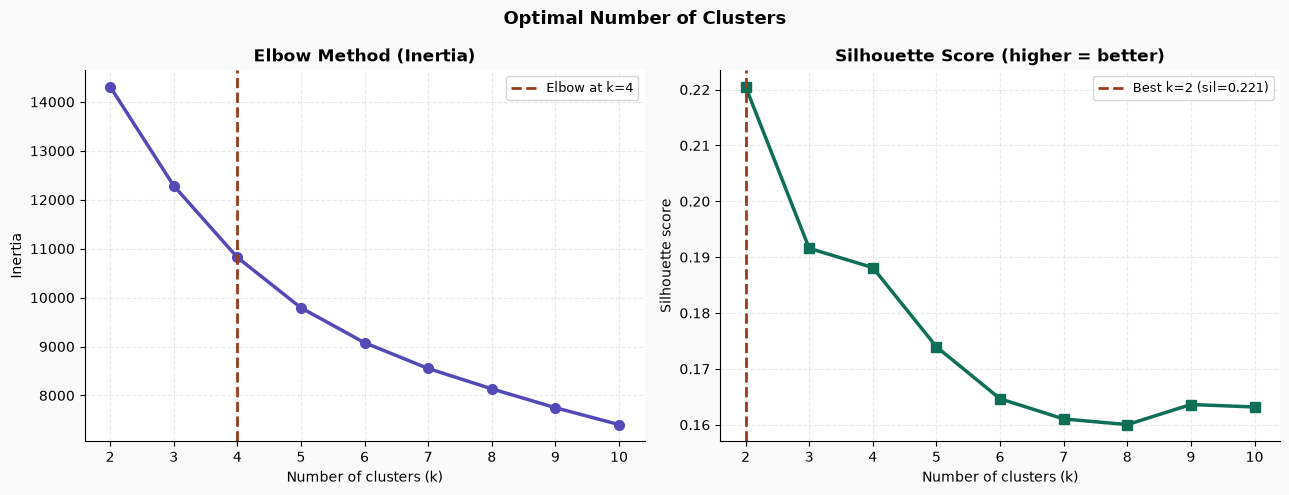

Elbow method suggests: k=4
Silhouette score peak: k=2 (score=0.2205)


In [ ]:
# Use first 5 PCs (captures ~75% variance, removes noise)
pca_seg = PCA(n_components=5, random_state=42)
X_pca5  = pca_seg.fit_transform(X_scaled)

print(f"Variance captured by 5 PCs: {pca_seg.explained_variance_ratio_.sum()*100:.1f}%")
print()

# ── Optimal cluster count: Elbow + Silhouette ─────────────────
inertias    = []
sil_scores  = []
k_range     = range(2, 11)

for k in k_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km_tmp.fit_predict(X_pca5)
    inertias.append(km_tmp.inertia_)
    sil_scores.append(silhouette_score(X_pca5, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Optimal Number of Clusters', fontsize=13, fontweight='bold')

axes[0].plot(list(k_range), inertias, color=PURPLE, linewidth=2.5,
             marker='o', markersize=7)
axes[0].axvline(4, color=CORAL, linewidth=2, linestyle='--', label='Elbow at k=4')
axes[0].set_title('Elbow Method (Inertia)', fontweight='bold')
axes[0].set_xlabel('Number of clusters (k)'); axes[0].set_ylabel('Inertia')
axes[0].legend(fontsize=9)

axes[1].plot(list(k_range), sil_scores, color=TEAL, linewidth=2.5,
             marker='s', markersize=7)
best_k = list(k_range)[np.argmax(sil_scores)]
axes[1].axvline(best_k, color=CORAL, linewidth=2, linestyle='--',
                label=f'Best k={best_k} (sil={max(sil_scores):.3f})')
axes[1].set_title('Silhouette Score (higher = better)', fontweight='bold')
axes[1].set_xlabel('Number of clusters (k)'); axes[1].set_ylabel('Silhouette score')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('p3_optimal_k.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Elbow method suggests: k=4")
print(f"Silhouette score peak: k={best_k} (score={max(sil_scores):.4f})")


# | பகுதி                | Code                   | X-Axis                 | Y-Axis           | எப்படி படிக்க வேண்டும்?                     | Rule                                              | உங்கள் Chart Interpretation                                   |
# | -------------------- | ---------------------- | ---------------------- | ---------------- | ------------------------------------------- | ------------------------------------------------- | ------------------------------------------------------------- |
# | **PCA**              | `PCA(n_components=5)`  | -                      | -                | Original features → 5 PCs ஆக குறைக்கிறது    | Variance ≥ 70% நல்லது                             | **5 PCs ≈ 75% variance** → நல்ல dimensionality reduction      |
# | **KMeans**           | `KMeans(n_clusters=k)` | k (Clusters)           | -                | k=2 முதல் k=10 வரை முயற்சிக்கிறது           | பல k values test செய்ய வேண்டும்                   | 2 முதல் 10 clusters வரை test செய்துள்ளீர்கள்                  |
# | **Inertia**          | `km_tmp.inertia_`      | Number of Clusters (k) | Inertia          | Inertia குறைவாக இருந்தால் cluster compact   | k அதிகரிக்கும்போது Inertia குறையும்               | 14300 → 7400 வரை குறைகிறது                                    |
# | **Elbow Method**     | Left Chart             | k                      | Inertia          | Line திடீரென bend ஆகும் இடம் பார்க்க        | Bend point = Optimal k                            | **k=4**-ல் elbow தெரிகிறது                                    |
# | **Silhouette Score** | `silhouette_score()`   | k                      | Silhouette Score | Score அதிகம் = நல்ல separation              | Highest score தேர்வு செய்யவும்                    | Highest = **0.221 at k=2**                                    |
# | **Silhouette Rule**  | -                      | -                      | -                | Clusters தெளிவா பிரிந்துள்ளதா?              | >0.7 Excellent, >0.5 Good, >0.25 Fair, <0.25 Weak | **0.221 → Weak clustering**                                   |
# | **Best k**           | `best_k=np.argmax()`   | -                      | -                | Highest silhouette உள்ள k                   | Highest score எடுத்துக்கொள்                       | **k=2**                                                       |
# | **Final Decision**   | Business Choice        | -                      | -                | Elbow + Silhouette இரண்டையும் compare செய்ய | Business meaning முக்கியம்                        | **k=4 (segments useful)** அல்லது **k=2 (statistically best)** |

# | Item            | Meaning                        | left chart
# | --------------- | ------------------------------ |
# | X-Axis          | Cluster Count (k)              |
# | Y-Axis          | Inertia (Within Cluster Error) |
# | Purple Line     | ஒவ்வொரு k-க்கும் Inertia       |
# | Red Dashed Line | Elbow Point                    |

# | Silhouette Score | தரம் (Rank)                     | விளக்கம்                              |
# | ---------------- | ------------------------------- | ------------------------------------- |
# | **0.70 – 1.00**  | ⭐⭐⭐⭐⭐ மிகச் சிறப்பு (Excellent) | Clusters மிகவும் தெளிவாக பிரிந்துள்ளன |
# | **0.50 – 0.69**  | ⭐⭐⭐⭐ நல்லது (Good)              | Clusters நன்றாக பிரிந்துள்ளன          |
# | **0.25 – 0.49**  | ⭐⭐⭐ பரவாயில்லை (Fair)           | Clusters ஓரளவு பிரிந்துள்ளன           |
# | **0.10 – 0.24**  | ⭐⭐ பலவீனம் (Weak)               | Clusters அதிகமாக overlap ஆகின்றன      |
# | **< 0.10**       | ⭐ மோசம் (Poor)                  | Clustering சரியாக அமையவில்லை          |


# 👉 "Silhouette Score = 0.2205 என்பதால் clusters இடையே separation பலவீனமாக உள்ளது. "
# "ஆனால் Elbow Method k=4 எனக் காட்டுவதால் business segmentation நோக்கில் k=4 பயன்படுத்தலாம்."

In [ ]:
# Fit final KMeans with k=4
n_clusters = 4
km_final = KMeans(n_clusters=n_clusters, random_state=42, n_init=20)
df_crm['segment'] = km_final.fit_predict(X_pca5)
df_crm['pc1'] = X_pca5[:,0]
df_crm['pc2'] = X_pca5[:,1]

sil_final = silhouette_score(X_pca5, df_crm['segment'])
print(f"Final model: k={n_clusters}, silhouette={sil_final:.4f}")
print()
print("Segment sizes:")
print(df_crm['segment'].value_counts().sort_index().to_string())

# | Code                   | என்ன செய்கிறது?                                                         |
# | ---------------------- | ----------------------------------------------------------------------- |
# | `n_clusters = 4`       | 4 குழுக்கள் (Segments) உருவாக்க வேண்டும் என்று முடிவு செய்கிறது         |
# | `KMeans(n_clusters=4)` | KMeans Model-ஐ 4 Clusters-உடன் உருவாக்குகிறது                           |
# | `fit_predict(X_pca5)`  | Data-வை Train செய்து ஒவ்வொரு Customer-ஐ ஒரு Segment-ல் assign செய்கிறது |
# | `df_crm['segment']`    | Customer எந்த Segment-ல் இருக்கிறார் என்பதை சேமிக்கிறது                 |
# | `df_crm['pc1']`        | PCA-வின் முதல் முக்கிய Component-ஐ சேமிக்கிறது                          |
# | `df_crm['pc2']`        | PCA-வின் இரண்டாவது முக்கிய Component-ஐ சேமிக்கிறது                      |
# | `silhouette_score()`   | Clustering quality-ஐ கணக்கிடுகிறது                                      |
# | `value_counts()`       | ஒவ்வொரு Segment-ல் எத்தனை Customers உள்ளனர் என்று எண்ணுகிறது            |

# | Item   | Meaning                             |
# | ------ | ----------------------------------- |
# | k=4    | 4 Customer Segments உருவாக்கப்பட்டன |
# | 0.1881 | Cluster quality score               | 👉 0.1881 = Weak Cluster Quality


# | Segment   | Customers | Interpretation    |
# | --------- | --------- | ----------------- |
# | Segment 0 | 403       | நடுத்தர அளவு குழு |
# | Segment 1 | 358       | நடுத்தர அளவு குழு |
# | Segment 2 | 142       | சிறிய குழு        |
# | Segment 3 | 597       | மிகப்பெரிய குழு   |

# | Segment         | Meaning                               | 🎯 Business Interpretation
# | --------------- | ------------------------------------- |
# | Segment 3 (597) | அதிக Customers இருக்கும் Main Group   |
# | Segment 2 (142) | Unique / Special Customers இருக்கலாம் |
# | Segment 0 & 1   | நடுத்தர வகை Customers                 |



Final model: k=4, silhouette=0.1881

Segment sizes:
segment
0    403
1    358
2    142
3    597


In [ ]:
# Rule:
# Income ↑ → பணக்கார Customers
# Spend Score ↑ → அதிகம் செலவு செய்பவர்கள்
# Frequency ↑ → அடிக்கடி வாங்குபவர்கள்
# Avg Order Value ↑ → ஒரு Order-க்கு அதிக பணம் செலவிடுபவர்கள்
# Recency Days ↑ → நீண்ட நாட்களாக வாங்காதவர்கள்
# CLV ↑ → Lifetime Value அதிகம்
# Engagement ↑ → App/Website-ல் அதிக Activity
# Churn Risk ↑ → விட்டு செல்லும் அபாயம் அதிகம்

# ── Segment profiling ─────────────────────────────────────────
profile_features = ['income_lpa','spend_score','frequency_pm','avg_order_val',
                    'recency_days','clv','engagement_score','nps_score',
                    'loyalty_years','churn_risk']

profile = df_crm.groupby('segment')[profile_features].mean().round(2)
print("SEGMENT PROFILES (mean values)")
print("="*70)
print(profile.T.to_string())

# Auto-label segments
print()
print("SEGMENT LABELS (auto-derived from profiles):")
labels_map = {}
for seg in range(n_clusters):
    row = profile.loc[seg]
    if row['income_lpa'] > profile['income_lpa'].mean() and row['clv'] > profile['clv'].mean():
        name = 'Champions'
    elif row['churn_risk'] > profile['churn_risk'].mean() and row['recency_days'] > profile['recency_days'].mean():
        name = 'At-Risk'
    elif row['frequency_pm'] > profile['frequency_pm'].mean():
        name = 'Loyal Regulars'
    else:
        name = 'Casual Shoppers'
    labels_map[seg] = name
    print(f"  Segment {seg}: {name}")
    print(f"    Income=₹{row['income_lpa']:.1f}L  CLV=₹{row['clv']:,.0f}  Churn={row['churn_risk']:.3f}")

df_crm['segment_name'] = df_crm['segment'].map(labels_map)

# | Metric     | Value  | Meaning                                 | 
# | ---------- | ------ | --------------------------------------- |
# | Income     | 32.19L | நல்ல Income                             |
# | Frequency  | 2.94   | அவ்வப்போது வாங்குகிறார்கள்              |
# | CLV        | 20,927 | நடுத்தர Value                           |
# | Engagement | 40.41  | Website/App அதிகம் பயன்படுத்துகிறார்கள் | 👉 "இவர்கள் அடிக்கடி வாங்கும் நிரந்தர Customers."

# | Metric     | Value  | Meaning                                 |
# | ---------- | ------ | --------------------------------------- |
# | Income     | 32.19L | நல்ல Income                             |
# | Frequency  | 2.94   | அவ்வப்போது வாங்குகிறார்கள்              |
# | CLV        | 20,927 | நடுத்தர Value                           |
# | Engagement | 40.41  | Website/App அதிகம் பயன்படுத்துகிறார்கள் | 👉 "இவர்கள் Browse செய்வார்கள், ஆனால் அடிக்கடி வாங்க மாட்டார்கள்."


# | Metric          | Value  | Meaning                  | 
# | --------------- | ------ | ------------------------ |
# | Avg Order Value | 755.13 | மிகவும் அதிகம்           |
# | CLV             | 96,926 | Highest                  |
# | Income          | 31.29L | நல்ல Income              |
# | Frequency       | 4.69   | அடிக்கடி வாங்குகிறார்கள் | 👉 "இவர்கள் நிறுவனத்தின் மிக மதிப்புமிக்க Customers." 👉 அதிக Revenue இங்கிருந்து வருகிறது.


# | Metric     | Value  | Meaning                    | 
# | ---------- | ------ | -------------------------- |
# | Income     | 23.15L | Lowest                     |
# | Frequency  | 1.93   | குறைவாக வாங்குகிறார்கள்    |
# | Recency    | 52.25  | நீண்ட நாட்களாக வாங்கவில்லை |
# | CLV        | 12,795 | Lowest                     |
# | Churn Risk | 0.51   | Highest                    | 👉 "இவர்கள் விட்டு செல்லக்கூடிய Customers." 👉 Retention Campaign தேவை.

# | Percentile  | Label            |
# | ----------- | ---------------- |
# | Top 25% CLV | Champions        |
# | 50–75%      | Loyal Customers  |
# | 25–50%      | Casual Customers |
# | Bottom 25%  | At-Risk          |

# | Row              | Meaning                               |
# | ---------------- | ------------------------------------- |
# | income_lpa       | அந்த Segment-ன் Average Income        |
# | spend_score      | Average Spend Score                   |
# | frequency_pm     | மாதத்திற்கு சராசரி Orders             |
# | avg_order_val    | ஒரு Order-க்கு சராசரி செலவு           |
# | recency_days     | கடைசியாக வாங்கி எத்தனை நாட்கள் ஆகிறது |
# | clv              | Average Customer Lifetime Value       |
# | engagement_score | Average Engagement                    |
# | nps_score        | Average Satisfaction                  |
# | loyalty_years    | Average Loyalty Years                 |
# | churn_risk       | Average Churn Risk                    |



SEGMENT PROFILES (mean values)
segment                  0         1         2         3
income_lpa           32.78     32.19     31.29     23.15
spend_score          35.75     37.30     34.65     33.16
frequency_pm          5.18      2.94      4.69      1.93
avg_order_val       228.88    283.24    755.13    266.16
recency_days         33.95     43.40     56.69     52.25
clv               32612.22  20926.56  96925.73  12795.01
engagement_score     29.96     40.41     30.62     26.48
nps_score             6.85      6.86      6.80      6.87
loyalty_years         2.28      2.60      2.25      2.49
churn_risk            0.39      0.44      0.43      0.51

SEGMENT LABELS (auto-derived from profiles):
  Segment 0: Loyal Regulars
    Income=₹32.8L  CLV=₹32,612  Churn=0.390
  Segment 1: Casual Shoppers
    Income=₹32.2L  CLV=₹20,927  Churn=0.440
  Segment 2: Champions
    Income=₹31.3L  CLV=₹96,926  Churn=0.430
  Segment 3: At-Risk
    Income=₹23.1L  CLV=₹12,795  Churn=0.510


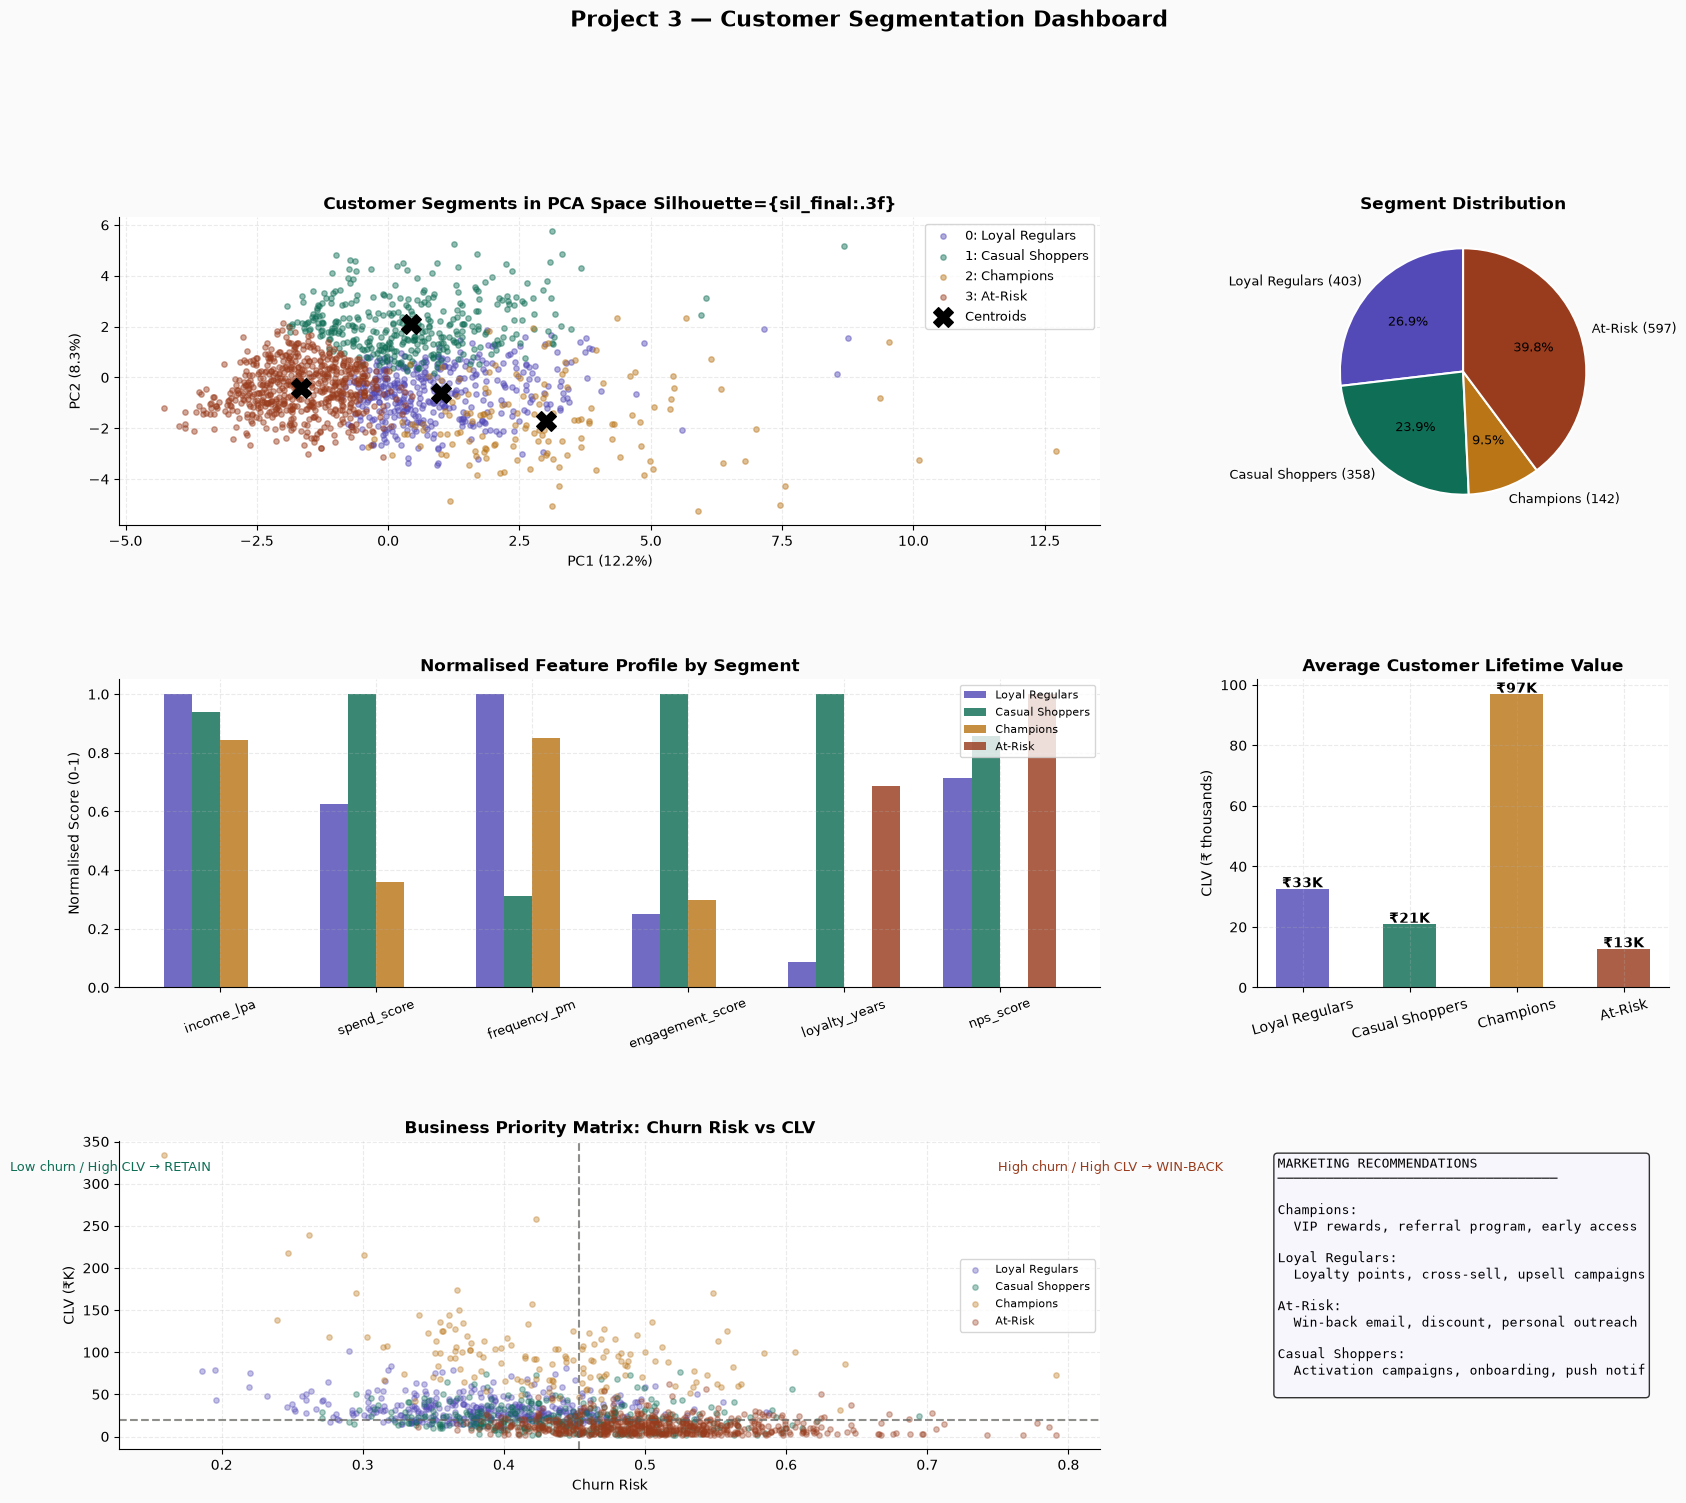

In [ ]:
fig = plt.figure(figsize=(20, 16))
fig.suptitle('Project 3 — Customer Segmentation Dashboard', fontsize=16, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.50, wspace=0.38)

# P1: PCA scatter with segments
ax1 = fig.add_subplot(gs[0, :2])
for seg, name in labels_map.items():
    mask = df_crm['segment'] == seg
    ax1.scatter(df_crm.loc[mask,'pc1'], df_crm.loc[mask,'pc2'],
                color=SEG_COLORS[seg], alpha=0.45, s=15, label=f'{seg}: {name}')
# Cluster centers in PCA space
centers_pca = km_final.cluster_centers_[:,:2]
ax1.scatter(centers_pca[:,0], centers_pca[:,1], color='black', s=200,
            marker='X', zorder=10, label='Centroids')
ax1.set_title('Customer Segments in PCA Space Silhouette={sil_final:.3f}',
              fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca_seg.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca_seg.explained_variance_ratio_[1]*100:.1f}%)')
ax1.legend(fontsize=9)

# P2: Segment size pie
ax2 = fig.add_subplot(gs[0, 2])
sizes  = [df_crm[df_crm['segment']==s].shape[0] for s in range(n_clusters)]
labels_pie = [f"{labels_map[s]} ({sizes[s]})" for s in range(n_clusters)]
ax2.pie(sizes, labels=labels_pie, colors=SEG_COLORS[:n_clusters],
        autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
        textprops={'fontsize':9})
ax2.set_title('Segment Distribution', fontweight='bold')

# P3: Spider / radar chart for profiles
# 1 = Highest in all segments
# 0 = Lowest in all segments
# Blue = 1
# Green = 0.95
# Orange = 0.85
# Brown = 0
# 👉 Loyal Regulars income highest
# 👉 At-Risk income lowest
ax3 = fig.add_subplot(gs[1, :2])
radar_feats = ['income_lpa','spend_score','frequency_pm',
               'engagement_score','loyalty_years','nps_score']
profile_norm = (profile[radar_feats] - profile[radar_feats].min()) /                (profile[radar_feats].max() - profile[radar_feats].min())
x_pos = np.arange(len(radar_feats))
bar_width = 0.18
for seg in range(n_clusters):
    bars = ax3.bar(x_pos + seg*bar_width, profile_norm.iloc[seg],
                   bar_width, color=SEG_COLORS[seg], alpha=0.82,
                   label=labels_map[seg])
ax3.set_xticks(x_pos + bar_width*1.5)
ax3.set_xticklabels(radar_feats, rotation=20, fontsize=9)
ax3.set_title('Normalised Feature Profile by Segment', fontweight='bold')
ax3.set_ylabel('Normalised Score (0-1)'); ax3.legend(fontsize=8)

# P4: CLV by segment (business value)


ax4 = fig.add_subplot(gs[1, 2])
clv_by_seg  = df_crm.groupby('segment')['clv'].mean()
seg_names_p = [labels_map[s] for s in clv_by_seg.index]
bars4 = ax4.bar(seg_names_p, clv_by_seg.values/1000,
                color=SEG_COLORS[:n_clusters], alpha=0.82, width=0.5)
for bar, v in zip(bars4, clv_by_seg.values/1000):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'₹{v:.0f}K', ha='center', fontweight='bold', fontsize=10)
ax4.set_title('Average Customer Lifetime Value', fontweight='bold')
ax4.set_ylabel('CLV (₹ thousands)'); ax4.tick_params(axis='x', rotation=15)

# P5: Churn risk vs CLV scatter (business priority matrix)
ax5 = fig.add_subplot(gs[2, :2])
for seg, name in labels_map.items():
    mask = df_crm['segment'] == seg
    ax5.scatter(df_crm.loc[mask,'churn_risk'], df_crm.loc[mask,'clv']/1000,
                color=SEG_COLORS[seg], alpha=0.35, s=15, label=name)
ax5.axvline(df_crm['churn_risk'].median(), color=DGRAY, linewidth=1.5,
            linestyle='--', alpha=0.7)
ax5.axhline(df_crm['clv'].median()/1000, color=DGRAY, linewidth=1.5,
            linestyle='--', alpha=0.7)
ax5.text(0.05, ax5.get_ylim()[1]*0.9, 'Low churn / High CLV → RETAIN', fontsize=9, color=TEAL)
ax5.text(0.75, ax5.get_ylim()[1]*0.9, 'High churn / High CLV → WIN-BACK', fontsize=9, color=CORAL)
ax5.set_title('Business Priority Matrix: Churn Risk vs CLV', fontweight='bold')
ax5.set_xlabel('Churn Risk'); ax5.set_ylabel('CLV (₹K)'); ax5.legend(fontsize=8)

# P6: Action recommendations
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
actions = [
    ('Champions',     'VIP rewards, referral program, early access'),
    ('Loyal Regulars','Loyalty points, cross-sell, upsell campaigns'),
    ('At-Risk',       'Win-back email, discount, personal outreach'),
    ('Casual Shoppers','Activation campaigns, onboarding, push notif'),
]
rec_text = "MARKETING RECOMMENDATIONS\n" + "─"*35 + "\n"
for name, action in actions:
    rec_text += f"\n{name}:\n  {action}\n"
ax6.text(0.05, 0.95, rec_text, transform=ax6.transAxes,
         fontsize=9, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#F8F6FF', alpha=0.8))

plt.tight_layout()
plt.savefig('p3_segmentation.png', dpi=130, bbox_inches='tight')
plt.show()

# | Chart                            | X-Axis                                 | Y-Axis              | Points/Bars Meaning                                       | உங்கள் Chart Interpretation                                                                                                                      |
# | -------------------------------- | -------------------------------------- | ------------------- | --------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------ |
# | **PCA Scatter Plot**             | PC1 (12.2%)                            | PC2 (8.3%)          | ஒவ்வொரு Dot = 1 Customer, Black X = Cluster Center        | At-Risk (Brown) இடது பக்கம், Champions (Orange) வலது பக்கம். சில clusters overlap ஆகின்றன. Silhouette = 0.188 என்பதால் separation weak.          |
# | **Segment Distribution Pie**     | இல்லை                                  | இல்லை               | Slice Size = Customer Count                               | At-Risk = 597 (39.8%) அதிகம். Champions = 142 (9.5%) குறைவு.                                                                                     |
# | **Normalized Feature Profile**   | Features (Income, Spend, Frequency...) | 0 முதல் 1 வரை Score | Bar உயரம் அதிகம் = அந்த feature-ல் அந்த segment strongest | Loyal Regulars → Frequency அதிகம். Casual Shoppers → Engagement அதிகம். Champions → Spend/Value அதிகம். At-Risk → NPS உயர்ந்தாலும் churn அதிகம். |
# | **Average CLV Bar Chart**        | Segment Name                           | CLV (₹K)            | Bar Height = Average CLV                                  | Champions ≈ ₹97K (Highest). At-Risk ≈ ₹13K (Lowest).                                                                                             |
# | **Business Priority Matrix**     | Churn Risk                             | CLV (₹K)            | Dot = 1 Customer                                          | மேல் = High CLV, வலது = High Churn. Champions மேலே, At-Risk வலது பக்கம் அதிகம்.                                                                  |
# | **Marketing Recommendation Box** | இல்லை                                  | இல்லை               | Business Actions                                          | Champions → VIP Rewards, At-Risk → Win Back Campaign.                                                                                            |

# | Item        | Meaning                           |
# | ----------- | --------------------------------- |
# | Blue Dots   | Loyal Regulars                    |
# | Green Dots  | Casual Shoppers                   |
# | Orange Dots | Champions                         |
# | Brown Dots  | At-Risk                           |
# | Black X     | அந்த Segment-ன் Center (Centroid) |


---
---
# 📊 Project 4 — MANOVA
## Multivariate Analysis of Variance

---

> 📌 **Tamil:** "MANOVA = Multiple ANOVAs ஒரே நேரத்தில் run பண்றது.  
> ANOVA: ஒரு outcome variable. MANOVA: பல outcome variables simultaneously.  
> Customer segments, purchase behaviour, engagement — எல்லாம் ஒரே time-ல் test பண்றோம்."

### When MANOVA > Multiple ANOVAs?
- Reduces Type I error (no Bonferroni needed across outcomes) - (தவறான Positive Result குறையும்)
- Captures correlations between outcome variables (ஒன்றுடன் ஒன்று தொடர்பு - Math Mark ↑ → Science Mark ↑, 
Purchase Amount ↑ → Customer Engagement ↑ )
- More statistical power when outcomes are correlated (உண்மையான Difference-ஐ கண்டுபிடிக்கும் திறன்-Math, Science marks இரண்டுக்கும் தொடர்பு இருக்கிறது. )

---

👉 ANOVA = ஒரு விஷயத்தை மட்டும் compare செய்வது.

Example:3 பள்ளி மாணவர்களின் Math Mark மட்டும் compare செய்வது.

👉 MANOVA = பல விஷயங்களை ஒரே நேரத்தில் compare செய்வது.

Example: 3 பள்ளி மாணவர்களின்

Math Mark, 
Science Mark, English Mark

இந்த 3 marks-ஐ ஒரே test-ல் compare செய்வது.

✅ 3. Error குறையும்

பல ANOVA run பண்ணினால் தவறான result வர வாய்ப்பு அதிகம். 
MANOVA அந்த risk-ஐ குறைக்கும்.




In [ ]:
from statsmodels.multivariate.manova import MANOVA
# இந்த 6 Outcome Variables-ல் வேறுபாடு இருக்கிறதா என்று பார்க்கிறீர்கள்:
# Test: Do the 4 segments(பாகம்) differ on MULTIPLE outcomes simultaneously?
outcomes = ['income_lpa','spend_score','frequency_pm',
            'avg_order_val','engagement_score','clv']
# | Variable         | Meaning                    |
# | ---------------- | -------------------------- |
# | income_lpa       | Income                     |
# | spend_score      | Spending Score             |
# | frequency_pm     | Monthly Purchase Frequency |
# | avg_order_val    | Average Order Value        |
# | engagement_score | Customer Engagement        |
# | clv              | Customer Lifetime Value    |

df_manova = df_crm[['segment_name'] + outcomes].copy() # தேவையான columns மட்டும் எடுக்கிறது.
df_manova.columns = ['segment'] + outcomes # column பெயரை short ஆக மாற்றுகிறது.

# Format for statsmodels MANOVA - "Segment மாறும்போது இந்த 6 variables-ம் சேர்த்து பார்த்தால் வேறுபாடு இருக்கிறதா?"
formula_outcomes = ' + '.join(outcomes)
manova = MANOVA.from_formula(f'{formula_outcomes} ~ segment', data=df_manova)
result = manova.mv_test()
print(result)

print()
print("INTERPRETING MANOVA RESULTS:")
print("  Wilks Lambda: 0=perfect separation, 1=no separation")
print("  p < 0.05 => Groups significantly differ on the combined outcome vector")

# Willks Lambda : range
# 0 → Groups completely different
# 1 → Groups same
# Wilks Lambda = 0.1023 - 0-க்கு மிகவும் அருகில் உள்ளது. அதாவது ✅ Segments ஒன்றுக்கொன்று மிகவும் வேறுபடுகின்றன.

# P Value: 
# Pr > F = 0.0000
# Rule: p < 0.05 என்றால் Significant.
# உங்கள் Result: 0.0000 < 0.05 அதனால் ✅ Significant Difference உள்ளது.

# | Table         | என்ன பார்க்கிறது?                                   | முக்கியமா?          |
# | ------------- | --------------------------------------------------- | ------------------- |
# | **Intercept** | Dataset-ன் overall mean 0-இல் இருந்து வேறுபடுகிறதா? | ❌ பொதுவாக Ignore    |
# | **Segment**   | Segments-க்கு இடையே வேறுபாடு இருக்கிறதா?            | ✅ இதுதான் முக்கியம் |

# --------------------------------------------------------------------------------------

# | Test            | Value   | p-value | Table 1: Intercept
# | --------------- | ------- | ------- |
# | Wilks Lambda    | 0.0734  | 0.0000  |
# | Pillai Trace    | 0.9266  | 0.0000  |
# | Hotelling Trace | 12.6233 | 0.0000  |
# | Roy Root        | 12.6233 | 0.0000  |
# இது: "மொத்த dataset-ன் average values zero-வுடன் ஒப்பிடும்போது வேறுபடுகிறதா?" என்று பார்க்கிறது.
# Customer Segmentation Analysis-ல் இதை பொதுவாக பார்க்க மாட்டோம். ✅ Ignore செய்யலாம்.


# | Test            | Value  | p-value | Table 2: Segment (Important)
# | --------------- | ------ | ------- |
# | Wilks Lambda    | 0.1023 | 0.0000  |
# | Pillai Trace    | 1.5453 | 0.0000  |
# | Hotelling Trace | 3.6779 | 0.0000  |
# | Roy Root        | 2.1381 | 0.0000  |
# இது: "Segment-கள் (Bronze, Silver, Gold, Platinum) Income, Spend, Frequency, CLV போன்ற metrics-ல் வேறுபடுகிறதா?" என்று பார்க்கிறது.

# | Test            | Easy Meaning                     |
# | --------------- | -------------------------------- |
# | Pillai Trace    | Difference அளவை அளக்கும்         |
# | Hotelling Trace | Difference Strength              |
# | Roy Root        | மிகப்பெரிய Difference-ஐ அளக்கும் |

# | Question        | Answer                                                                                                        |
# | --------------- | ------------------------------------------------------------------------------------------------------------- |
# | Intercept Table | Overall Mean Test (Ignore)                                                                                    |
# | Segment Table   | Segment Difference Test (Important)                                                                           |
# | Wilks Lambda    | 0.1023 (0-க்கு அருகில்)                                                                                       |
# | p-value         | 0.0000 (<0.05)                                                                                                |
# | Conclusion      | Customer Segments-க்கு Income, Spend, Frequency, Engagement, CLV ஆகியவற்றில் குறிப்பிடத்தக்க வேறுபாடு உள்ளது. |


                    Multivariate linear model
                                                                 
-----------------------------------------------------------------
       Intercept         Value  Num DF   Den DF   F Value  Pr > F
-----------------------------------------------------------------
          Wilks' lambda  0.0734 6.0000 1491.0000 3136.8910 0.0000
         Pillai's trace  0.9266 6.0000 1491.0000 3136.8910 0.0000
 Hotelling-Lawley trace 12.6233 6.0000 1491.0000 3136.8910 0.0000
    Roy's greatest root 12.6233 6.0000 1491.0000 3136.8910 0.0000
-----------------------------------------------------------------
                                                                 
-----------------------------------------------------------------
         segment         Value   Num DF   Den DF  F Value  Pr > F
-----------------------------------------------------------------
           Wilks' lambda 0.1023 18.0000 4217.6701 290.3721 0.0000
          Pillai's trace 1.545

In [ ]:
# MANOVA சொன்னது: "Segments-க்கு overall difference இருக்கு" ஆனால்... ❓ எந்த metric-ல் difference இருக்கு? அதை கண்டுபிடிக்க Post-MANOVA ANOVA பயன்படுத்துகிறோம்.
# Follow up with individual ANOVAs (post-MANOVA)
print("UNIVARIATE FOLLOW-UP ANOVAs (post-MANOVA):")
print("="*55)
print(f"{'Outcome':<22} {'F':>8} {'p-value':>10} {'Sig?':>7}")
print("-"*50)
for outcome in outcomes: # ஒரு metric-ஆக எடுக்கிறது.
    groups = [df_manova[df_manova['segment']==s][outcome].values
              for s in df_manova['segment'].unique()] # ஒவ்வொரு Segment-ன் values-ஐ பிரிக்கிறது.
    F, p = stats.f_oneway(*groups)
    print(f"  {outcome:<20} {F:>8.3f} {p:>10.4f}   {'Yes' if p<0.05 else 'No'}") 

print()
print("  ► All significant → segments are meaningfully distinct on every metric")
print("  ► Use eta-squared from each ANOVA to rank which metric distinguishes most")


# | F Value | Meaning          |
# | ------- | ---------------- |
# | Small   | Groups Similar   |
# | Large   | Groups Different | Example: F = 5 - சிறிய difference ; F = 500 - பெரிய difference

# | p-value | Meaning         |
# | ------- | --------------- |
# | < 0.05  | Significant     |
# | > 0.05  | Not Significant |

# --------------------------------------------------------------------------------------------
# F Value Interpretation : F Value அதிகமாக இருந்தால் 👉 Segments-க்கு இடையேயான Difference அதிகம்.

# 🥇 CLV (903.413) - மிகப்பெரிய வேறுபாடு.
# அதாவது: Customer Segments-ஐ பிரிப்பதில் CLV தான் மிக முக்கியமான metric.

# 🥈 Avg Order Value (496.876) - ஒவ்வொரு purchase-க்கும் செலவழிக்கும் தொகையில் Segments வேறுபடுகின்றன.

# 🥉 Frequency (438.179) - எவ்வளவு அடிக்கடி வாங்குகிறார்கள் என்பதிலும் பெரிய வேறுபாடு உள்ளது.

# Engagement (386.190) - Customer engagement-லும் நல்ல வேறுபாடு உள்ளது.

# Income (36.506) - Difference உள்ளது. ஆனால் CLV, Frequency அளவுக்கு இல்லை.

# Spend Score (21.852) - Difference உள்ளது. ஆனால் மற்ற metrics-ஐ விட குறைவாக Segment-களை பிரிக்கிறது.

# All significant → அனைத்து metrics-லும் Segments வேறுபடுகின்றன.
# Eta-Squared → எந்த metric Segments-ஐ அதிகமாக பிரிக்கிறது என்பதை அளக்கும் அளவுகோல். 🎯


UNIVARIATE FOLLOW-UP ANOVAs (post-MANOVA):
Outcome                       F    p-value    Sig?
--------------------------------------------------
  income_lpa             36.506     0.0000   Yes
  spend_score            21.852     0.0000   Yes
  frequency_pm          438.179     0.0000   Yes
  avg_order_val         496.876     0.0000   Yes
  engagement_score      386.190     0.0000   Yes
  clv                   903.413     0.0000   Yes

  ► All significant → segments are meaningfully distinct on every metric
  ► Use eta-squared from each ANOVA to rank which metric distinguishes most


---
---
# 🧪 Project 5 — Two-Way ANOVA + Interaction Effects
## Factorial Experiment Design: Price × Channel

---

> 📌 **Tamil:** "Two-way ANOVA = இரண்டு factors ஒரே நேரத்தில் test பண்றோம்.  
> Interaction effect = Factor A-இன் effect, Factor B-இன் level-ஐ பொறுத்து மாறுகிறதா?  
> 'Discount works on Email but not on Push' → interaction effect!"

### The Experiment
A retail brand tests: **Discount level** (10%, 20%, 30%) × **Channel** (Email, Push, SMS)  
= 3 × 3 = 9 treatment combinations, 50 customers each (450 total) 9 Combinations × 50 Customers = 450 Customers

**Hypotheses:**
- H₀₁: No discount effect on revenue (iscount மாற்றினாலும் Revenue மாறாது.)
- H₀₂: No channel effect on revenue (Email, Push, SMS எதுவாக இருந்தாலும் Revenue ஒரே மாதிரி இருக்கும்.)
- H₀₃: No interaction effect (discount effect is same across channels) (Discount-ன் effect எல்லா Channels-லுமே ஒரே மாதிரி இருக்கும்.)

---

> One-Way ANOVA → ஒரு Factor மட்டும் பார்க்கும்.
> Two-Way ANOVA → இரண்டு Factors-ஐ ஒரே நேரத்தில் பார்க்கும்.

Example : Factor 1: Discount => 10%, 20%, 30%

Factor 2: Channel => Email, Push, SMS

Interaction Effect என்றால் என்ன? : 👉 ஒரு Factor-ன் effect, மற்றொரு Factor-ஐ பொறுத்து மாறுகிறதா?

| Channel | 10% Discount | 30% Discount |
| ------- | ------------ | ------------ |
| Email   | ₹1000        | ₹2000        |
| Push    | ₹1000        | ₹1100        |

இங்கே Email-ல் Discount நல்ல வேலை செய்கிறது. Push-ல் Discount பெரிதாக வேலை செய்யவில்லை. ✅ இதுதான் Interaction Effect.

---

| Discount | Channel |
| -------- | ------- |
| 10%      | Email   |
| 10%      | Push    |
| 10%      | SMS     |
| 20%      | Email   |
| 20%      | Push    |
| 20%      | SMS     |
| 30%      | Email   |
| 30%      | Push    |
| 30%      | SMS     |

👉 மொத்தம் 9 combinations ஒவ்வொரு Combination-க்கும் 50 Customers கொடுக்கப்படுகிறார்கள்.
உதாரணம்:

10% + Email → 50 Customers, 

10% + Push → 50 Customers , 

...  , 

30% + SMS → 50 Customers

In [ ]:
# இந்த Code ஒரு Retail Marketing Experiment Dataset உருவாக்குகிறது.
# கேள்வி: "எந்த Discount + Channel சேர்க்கை அதிக Revenue தருகிறது?"

np.random.seed(123)
n_per_cell = 50

discounts = [10, 20, 30]
channels  = ['Email', 'Push', 'SMS']

# True effects (what's actually happening in the world)
# Email: discounts work well; Push: moderate; SMS: minimal
true_effects = {
    ('Email', 10): 1200, ('Email', 20): 1600, ('Email', 30): 2100,
    ('Push',  10): 1100, ('Push',  20): 1350, ('Push',  30): 1450,
    ('SMS',   10): 1050, ('SMS',   20): 1150, ('SMS',   30): 1200,
}

records_exp = []
for ch in channels:
    for disc in discounts:
        true_mean = true_effects[(ch, disc)]
        revenues  = np.random.normal(true_mean, 280, n_per_cell)
        for r in revenues:
            records_exp.append({
                'channel' : ch,
                'discount': disc,
                'revenue' : max(100, round(r, 2))
            })

df_exp = pd.DataFrame(records_exp)
df_exp.to_csv('experiment_factorial.csv', index=False)
print(f"Factorial experiment dataset: {len(df_exp)} observations")
print(f"  3 discount levels x 3 channels x {n_per_cell} customers = {len(df_exp)}")
print()

# Cell means
cell_means = df_exp.groupby(['channel','discount'])['revenue'].agg(['mean','std','count'])
print("Cell means (revenue ₹):")
print(cell_means.round(1).to_string())

# | Feature (Column) | தமிழ் பெயர்               | என்ன அர்த்தம்?                                                                            | Example             | வகை                           |
# | ---------------- | ------------------------- | ----------------------------------------------------------------------------------------- | ------------------- | ----------------------------- |
# | **channel**      | தகவல் அனுப்பிய வழி        | Offer அல்லது Discount Customer-க்கு எந்த வழியில் அனுப்பப்பட்டது என்பதை குறிக்கும்         | Email, Push, SMS    | Independent Variable (Factor) |
# | **discount**     | தள்ளுபடி சதவீதம்          | Customer-க்கு எவ்வளவு % Discount கொடுக்கப்பட்டது என்பதை குறிக்கும்                        | 10%, 20%, 30%       | Independent Variable (Factor) |
# | **revenue**      | வருவாய் / விற்பனை மதிப்பு | Customer அந்த Offer-ஐ பார்த்த பிறகு எவ்வளவு ரூபாய் மதிப்பில் வாங்கினார் என்பதை குறிக்கும் | ₹1200, ₹1650, ₹2100 | Dependent Variable (Outcome)  |

# | Factor       | கேள்வி                                      |
# | ------------ | ------------------------------------------- |
# | **Channel**  | Email, Push, SMS-ல் எது சிறந்தது?           |
# | **Discount** | 10%, 20%, 30%-ல் எது அதிக Revenue தருகிறது? |
# | **Revenue**  | இறுதியாக Customer எவ்வளவு வாங்கினார்?       |

# | Feature  | Type                                  |
# | -------- | ------------------------------------- |
# | channel  | Factor 1 (Independent Variable)       |
# | discount | Factor 2 (Independent Variable)       |
# | revenue  | Outcome Variable (Dependent Variable) |

# | Value | Meaning                        |
# | ----- | ------------------------------ |
# | Email | Email மூலம்                    |
# | Push  | Mobile Push Notification மூலம் |
# | SMS   | Text Message மூலம்             |



Factorial experiment dataset: 450 observations
  3 discount levels x 3 channels x 50 customers = 450

Cell means (revenue ₹):
                    mean    std  count
channel discount                      
Email   10        1203.7  336.5     50
        20        1611.5  300.7     50
        30        2133.4  285.0     50
Push    10        1055.7  257.4     50
        20        1316.9  242.4     50
        30        1429.8  302.6     50
SMS     10        1038.8  243.7     50
        20        1086.4  251.1     50
        30        1197.8  286.9     50


In [ ]:
# இந்த Code Two-Way ANOVA மூலம் 3 விஷயங்களை சோதிக்கிறது:
# Channel Revenue-ஐ பாதிக்கிறதா?
# Discount Revenue-ஐ பாதிக்கிறதா?
# Discount-ன் Effect, Channel-ஐ பொறுத்து மாறுகிறதா? (Interaction Effect)

# ── TWO-WAY ANOVA ─────────────────────────────────────────────
model_2way = ols('revenue ~ C(channel) + C(discount) + C(channel):C(discount)',
                 data=df_exp).fit()
anova_table = sm.stats.anova_lm(model_2way, typ=2)
print("TWO-WAY ANOVA TABLE")
print("="*70)
print(anova_table.round(4).to_string())
print()

# Effect sizes (eta-squared)
ss_total = anova_table['sum_sq'].sum()
print("EFFECT SIZES (eta-squared = SS_effect / SS_total):")
for term in anova_table.index[:-1]:
    eta2 = anova_table.loc[term,'sum_sq'] / ss_total
    size = 'large' if eta2>0.14 else 'medium' if eta2>0.06 else 'small'
    print(f"  {term:<45}: eta² = {eta2:.4f}  ({size} effect)")

print()
# Interpret interaction
p_interaction = anova_table.loc['C(channel):C(discount)','PR(>F)']
print(f"  INTERACTION EFFECT p = {p_interaction:.4f}")
if p_interaction < 0.05:
    print("  Significant interaction detected!")
    print("  => Discount effectiveness DEPENDS on the channel")
    print("  => Cannot interpret main effects in isolation!")
    print("  => Must plot interaction plot to understand the pattern")
else:
    print("  No significant interaction — main effects are independent")

# | Part                   | Meaning            |
# | ---------------------- | ------------------ |
# | revenue                | Dependent Variable |
# | C(channel)             | Channel Effect     | Channel Revenue-ஐ பாதிக்கிறதா?
# | C(discount)            | Discount Effect    | Discount Revenue-ஐ பாதிக்கிறதா?
# | C(channel):C(discount) | Interaction Effect | Discount-ன் தாக்கம் Channel-க்கு Channel மாறுகிறதா?

# | Eta²        | Meaning |
# | ----------- | ------- |
# | < 0.06      | Small   |
# | 0.06 - 0.14 | Medium  |
# | > 0.14      | Large   |
# example :
# | Factor      | Eta² |
# | ----------- | ---- |
# | Discount    | 0.45 |
# | Channel     | 0.20 |
# | Interaction | 0.15 | அர்த்தம்: 👉 Revenue-ஐ அதிகமாக பாதிப்பது Discount.

# | Factor                 | என்ன சோதிக்கிறது?                                | F Value | p-value | Rule     | Result      | தமிழ் விளக்கம்                                           |
# | ---------------------- | ------------------------------------------------ | ------: | ------: | -------- | ----------- | -------------------------------------------------------- |
# | **Channel**            | Email, Push, SMS Revenue-ஐ பாதிக்கிறதா?          | 148.197 |  0.0000 | p < 0.05 | Significant | Channel மாறினால் Revenue மாறுகிறது                       |
# | **Discount**           | 10%, 20%, 30% Revenue-ஐ பாதிக்கிறதா?             | 113.659 |  0.0000 | p < 0.05 | Significant | Discount மாறினால் Revenue மாறுகிறது                      |
# | **Channel × Discount** | Discount-ன் Effect Channel-ஐ பொறுத்து மாறுகிறதா? |  26.220 |  0.0000 | p < 0.05 | Significant | Discount எல்லா Channels-லுமே ஒரே மாதிரி வேலை செய்யவில்லை |

# | Factor          |   Eta² | Effect Size | Revenue Variation-ல் விளக்கும் பகுதி |
# | --------------- | -----: | ----------- | ------------------------------------ |
# | **Channel**     | 0.2771 | Large       | 27.71%                               |
# | **Discount**    | 0.2125 | Large       | 21.25%                               |
# | **Interaction** | 0.0981 | Medium      | 9.81%                                |

# | Question                          | Answer                               |
# | --------------------------------- | ------------------------------------ |
# | Channel Revenue-ஐ பாதிக்கிறதா?    | ✅ ஆம்                                |
# | Discount Revenue-ஐ பாதிக்கிறதா?   | ✅ ஆம்                                |
# | Interaction Effect இருக்கிறதா?    | ✅ ஆம்                                |
# | மிக முக்கியமான Factor எது?        | 🥇 Channel                           |
# | இரண்டாவது முக்கியமான Factor?      | 🥈 Discount                          |
# | Interaction முக்கியமா?            | ✅ ஆம் (Medium Effect)                |
# | Main Effects-ஐ தனியாக விளக்கலாமா? | ❌ முடியாது                           |
# | அடுத்து என்ன செய்ய வேண்டும்?      | 📈 Interaction Plot பார்க்க வேண்டும் |

# | Term                       | தமிழ் அர்த்தம்                | என்ன பார்க்கிறது?                                     | Example Question                                                  |
# | -------------------------- | ----------------------------- | ----------------------------------------------------- | ----------------------------------------------------------------- |
# | **Main Effect (Channel)**  | Channel-ன் தனிப்பட்ட தாக்கம்  | Discount-ஐ கவனிக்காமல் Channel Revenue-ஐ பாதிக்கிறதா? | Email, Push, SMS-ல் Revenue வேறுபடுகிறதா?                         |
# | **Main Effect (Discount)** | Discount-ன் தனிப்பட்ட தாக்கம் | Channel-ஐ கவனிக்காமல் Discount Revenue-ஐ பாதிக்கிறதா? | 10%, 20%, 30% Discount-ல் Revenue வேறுபடுகிறதா?                   |
# | **Interaction Effect**     | இணைந்த தாக்கம்                | Discount-ன் Effect Channel-க்கு Channel மாறுகிறதா?    | Email-ல் வேலை செய்யும் Discount, SMS-லும் அதேபோல் வேலை செய்கிறதா? |


👉 Discount எவ்வளவு பயனுள்ளதாக செயல்படுகிறது என்பது Channel-ஐ (Email, Push, SMS) பொறுத்து மாறுகிறது.

👉 Channel மற்றும் Discount ஆகியவற்றின் தனிப்பட்ட (Main) Effects-ஐ தனியாக விளக்கக்கூடாது.
👉 இரண்டையும் சேர்த்து பார்த்து விளக்க வேண்டும்.

👉 இந்த தொடர்பின் (Interaction) உண்மையான வடிவத்தைப் புரிந்துகொள்ள Interaction Plot (Graph) கட்டாயம் வரைய வேண்டும்.

TWO-WAY ANOVA TABLE
                              sum_sq     df         F  PR(>F)
C(channel)              2.325449e+07    2.0  148.1970     0.0
C(discount)             1.783494e+07    2.0  113.6591     0.0
C(channel):C(discount)  8.228839e+06    4.0   26.2205     0.0
Residual                3.459999e+07  441.0       NaN     NaN

EFFECT SIZES (eta-squared = SS_effect / SS_total):
  C(channel)                                   : eta² = 0.2771  (large effect)
  C(discount)                                  : eta² = 0.2125  (large effect)
  C(channel):C(discount)                       : eta² = 0.0981  (medium effect)

  INTERACTION EFFECT p = 0.0000
  Significant interaction detected!
  => Discount effectiveness DEPENDS on the channel
  => Cannot interpret main effects in isolation!
  => Must plot interaction plot to understand the pattern


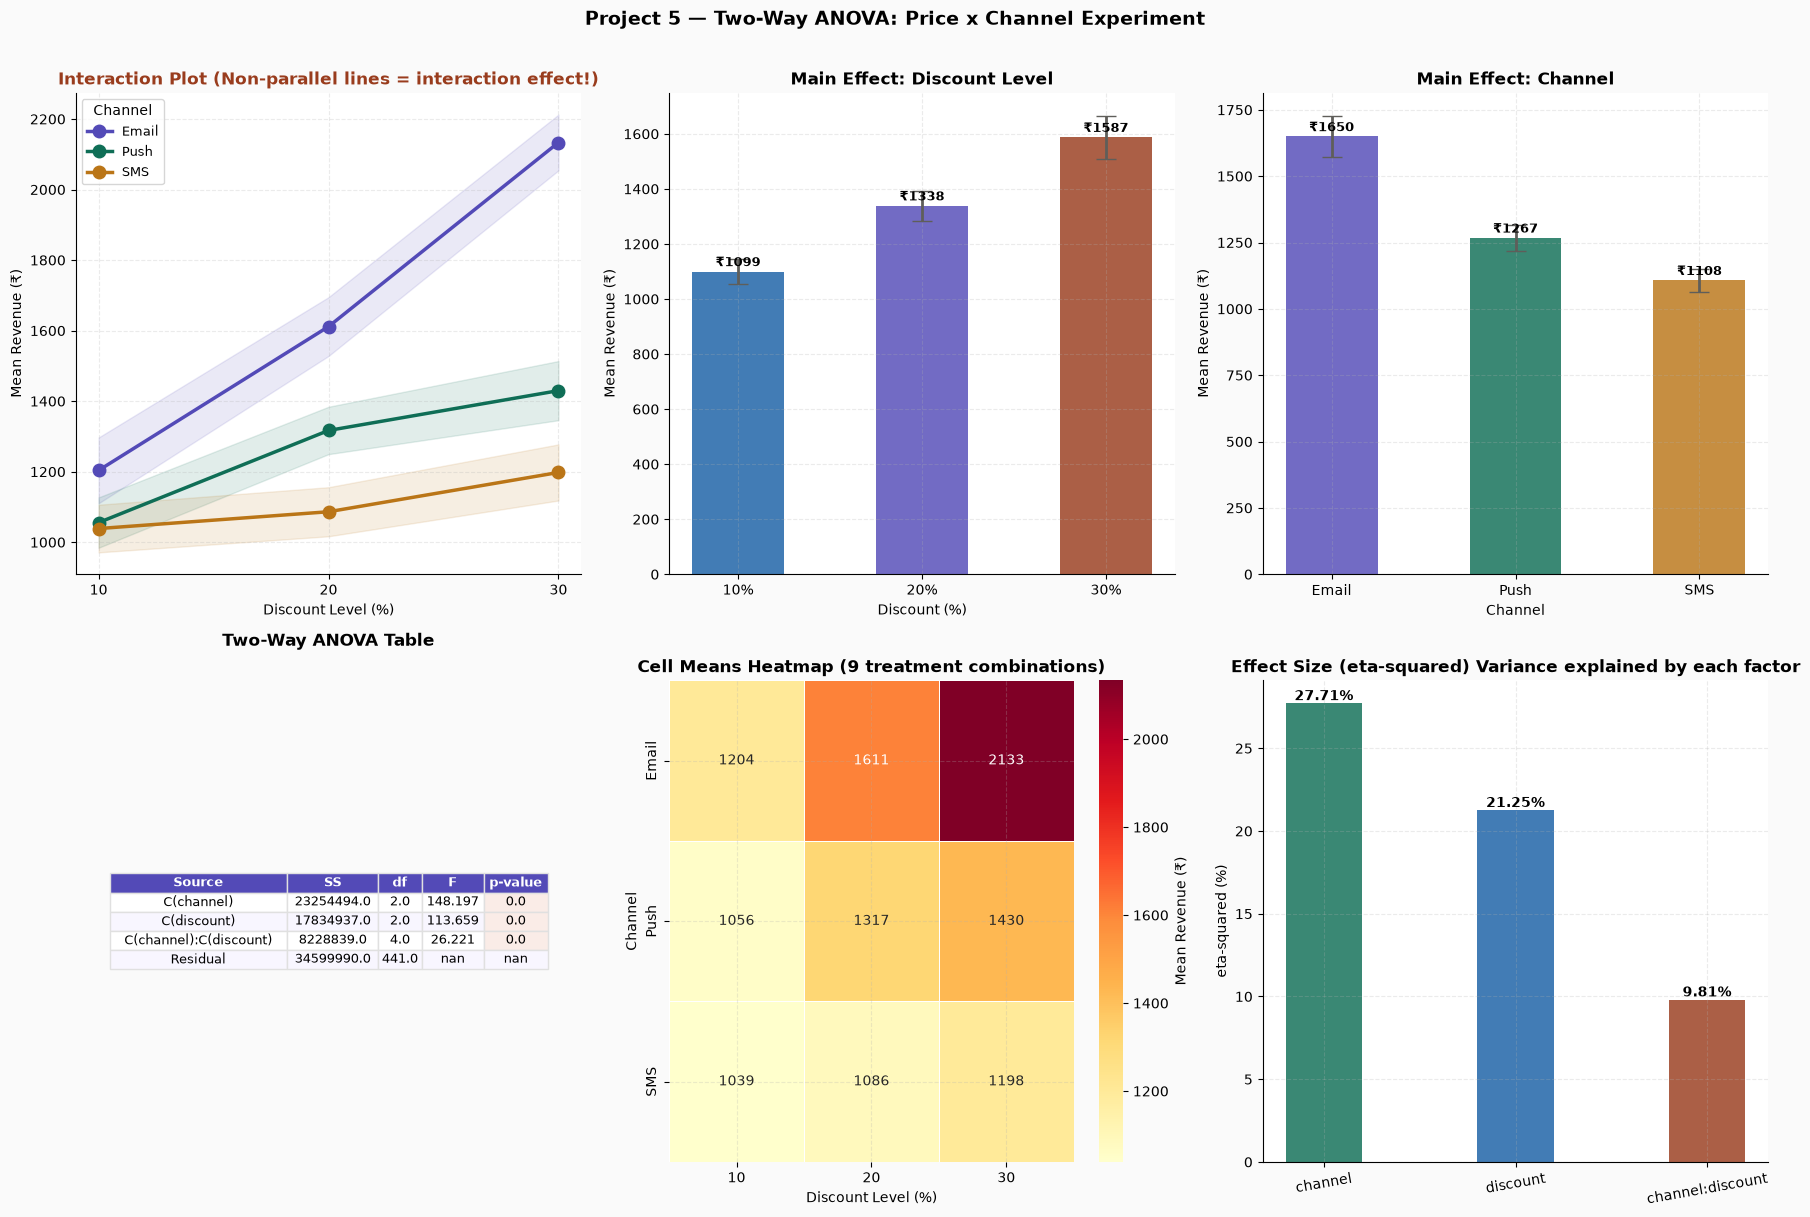

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Project 5 — Two-Way ANOVA: Price x Channel Experiment',
             fontsize=14, fontweight='bold', y=1.01)

ch_colors = {'Email':PURPLE, 'Push':TEAL, 'SMS':AMBER}

# P1: Interaction plot (the key visualization)
ax1 = axes[0,0]
for ch, col in ch_colors.items():
    ch_data = df_exp[df_exp['channel']==ch].groupby('discount')['revenue'].mean()
    ax1.plot(ch_data.index, ch_data.values, color=col, linewidth=2.5,
             marker='o', markersize=9, label=ch)
    ax1.fill_between(ch_data.index,
                     df_exp[df_exp['channel']==ch].groupby('discount')['revenue'].mean() -
                     df_exp[df_exp['channel']==ch].groupby('discount')['revenue'].sem()*1.96,
                     df_exp[df_exp['channel']==ch].groupby('discount')['revenue'].mean() +
                     df_exp[df_exp['channel']==ch].groupby('discount')['revenue'].sem()*1.96,
                     alpha=0.12, color=col)
ax1.set_title('Interaction Plot (Non-parallel lines = interaction effect!)',
              fontweight='bold', color=CORAL)
ax1.set_xlabel('Discount Level (%)'); ax1.set_ylabel('Mean Revenue (₹)')
ax1.legend(title='Channel', fontsize=9)
ax1.set_xticks(discounts)

# P2: Main effect — discount
ax2 = axes[0,1]
disc_means = df_exp.groupby('discount')['revenue'].agg(['mean','sem'])
ax2.bar(disc_means.index.astype(str), disc_means['mean'],
        color=[BLUE,PURPLE,CORAL], alpha=0.82, width=0.5)
ax2.errorbar(range(3), disc_means['mean'],
             yerr=disc_means['sem']*1.96,
             fmt='none', color=DGRAY, capsize=7, linewidth=2)
for i,(idx,row) in enumerate(disc_means.iterrows()):
    ax2.text(i, row['mean']+20, f'₹{row["mean"]:.0f}',
             ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Main Effect: Discount Level', fontweight='bold')
ax2.set_xlabel('Discount (%)'); ax2.set_ylabel('Mean Revenue (₹)')
ax2.set_xticks(range(3)); ax2.set_xticklabels(['10%','20%','30%'])

# P3: Main effect — channel
ax3 = axes[0,2]
ch_means = df_exp.groupby('channel')['revenue'].agg(['mean','sem'])
bars3 = ax3.bar(ch_means.index, ch_means['mean'],
                color=[PURPLE,TEAL,AMBER], alpha=0.82, width=0.5)
ax3.errorbar(range(3), ch_means['mean'],
             yerr=ch_means['sem']*1.96,
             fmt='none', color=DGRAY, capsize=7, linewidth=2)
for bar, (idx,row) in zip(bars3, ch_means.iterrows()):
    ax3.text(bar.get_x()+bar.get_width()/2, row['mean']+20,
             f'₹{row["mean"]:.0f}', ha='center', fontsize=9, fontweight='bold')
ax3.set_title('Main Effect: Channel', fontweight='bold')
ax3.set_xlabel('Channel'); ax3.set_ylabel('Mean Revenue (₹)')

# P4: ANOVA table visualisation

ax4 = axes[1,0]
ax4.axis('off')
anova_display = anova_table.reset_index()
anova_display.columns = ['Source','SS','df','F','p-value']
anova_display['SS']  = anova_display['SS'].round(0) # ss means variation
anova_display['F']   = anova_display['F'].round(3)
anova_display['p-value'] = anova_display['p-value'].round(4)
tbl4 = ax4.table(cellText=anova_display.values,
                  colLabels=anova_display.columns,
                  loc='center', cellLoc='center')
tbl4.auto_set_font_size(False); tbl4.set_fontsize(9)
tbl4.auto_set_column_width(range(5))
for (r,c), cell in tbl4.get_celld().items():
    cell.set_edgecolor('#E0E0E0')
    if r==0: cell.set_facecolor(PURPLE); cell.set_text_props(color='white',fontweight='bold')
    elif r%2==0: cell.set_facecolor('#F8F6FF')
    if r>0 and c==4:
        p_val = float(anova_display['p-value'].iloc[r-1])
        if p_val < 0.05: cell.set_facecolor('#FAECE7')
ax4.set_title('Two-Way ANOVA Table', fontweight='bold', pad=25)

# P5: Cell means heatmap
# | Color        | Meaning         |
# | ------------ | --------------- |
# | Light Yellow | குறைந்த Revenue |
# | Dark Red     | அதிக Revenue    |

ax5 = axes[1,1]
pivot_means = df_exp.groupby(['channel','discount'])['revenue'].mean().unstack()
sns.heatmap(pivot_means, annot=True, fmt='.0f', cmap='YlOrRd',
            ax=ax5, linewidths=0.5, linecolor='white',
            cbar_kws={'label':'Mean Revenue (₹)'})
ax5.set_title('Cell Means Heatmap (9 treatment combinations)', fontweight='bold')
ax5.set_xlabel('Discount Level (%)'); ax5.set_ylabel('Channel')

# P6: Effect size comparison
ax6 = axes[1,2]
effects = [(term.replace('C(','').replace(')',''), eta2)
           for term in anova_table.index[:-1]
           for eta2 in [anova_table.loc[term,'sum_sq']/ss_total]]
effect_names = [e[0] for e in effects]
effect_vals  = [e[1]*100 for e in effects]
bars6 = ax6.bar(effect_names, effect_vals,
                color=[TEAL,BLUE,CORAL], alpha=0.82, width=0.4)
for bar, v in zip(bars6, effect_vals):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
             f'{v:.2f}%', ha='center', fontsize=10, fontweight='bold')
ax6.set_title('Effect Size (eta-squared) Variance explained by each factor', fontweight='bold')
ax6.set_ylabel('eta-squared (%)'); ax6.tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig('p5_twoway_anova.png', dpi=130, bbox_inches='tight')
plt.show()


# | Chart                     | X-Axis (கிடைமட்ட அச்சு)                  | Y-Axis (நெடுமட்ட அச்சு)  | என்ன காட்டுகிறது?                                                | முக்கிய Observation                                                                   | Business Conclusion                                                           |
# | ------------------------- | ---------------------------------------- | ------------------------ | ---------------------------------------------------------------- | ------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------- |
# | **Interaction Plot**      | Discount (10%, 20%, 30%)                 | Mean Revenue (₹)         | Discount மற்றும் Channel சேர்ந்து Revenue-ஐ எப்படி பாதிக்கின்றன  | Email Line மிகவும் வேகமாக உயர்கிறது; SMS Line மெதுவாக உயர்கிறது; Lines Parallel இல்லை | ✅ Interaction Effect உள்ளது. Discount-ன் தாக்கம் Channel-ஐ பொறுத்து மாறுகிறது |
# | **Main Effect: Discount** | Discount Levels                          | Mean Revenue (₹)         | எல்லா Channels-யும் சேர்த்து ஒவ்வொரு Discount-ன் Average Revenue | ₹1099 → ₹1338 → ₹1587                                                                 | ✅ Discount அதிகரிக்க Revenue அதிகரிக்கிறது                                    |
# | **Main Effect: Channel**  | Email, Push, SMS                         | Mean Revenue (₹)         | எல்லா Discounts-யும் சேர்த்து ஒவ்வொரு Channel-ன் Average Revenue | Email = ₹1650, Push = ₹1267, SMS = ₹1108                                              | ✅ Email சிறந்த Channel                                                        |
# | **ANOVA Table**           | Factors (Channel, Discount, Interaction) | F, p-value               | Statistical Significance                                         | மூன்றிற்கும் p = 0.0000                                                               | ✅ Channel, Discount, Interaction மூன்றும் Significant                         |
# | **Heatmap**               | Discount (10%,20%,30%)                   | Channel (Email,Push,SMS) | 9 Combinations-ன் Mean Revenue                                   | Email + 30% = ₹2133 (Highest), SMS + 10% = ₹1039 (Lowest)                             | 🏆 Best Combination = Email + 30% Discount                                    |
# | **Effect Size (η²)**      | Factors                                  | Variance Explained (%)   | Revenue-ல் ஒவ்வொரு Factor-ன் தாக்கம்                             | Channel = 27.71%, Discount = 21.25%, Interaction = 9.81%                              | ✅ Channel தான் மிகப்பெரிய தாக்கம் செலுத்துகிறது                               |


---
---
# 📋 Multivariate Statistics — Cheat Sheet

In [23]:
print("="*70)
print("  MULTIVARIATE STATISTICS — PYTHON REFERENCE")
print("="*70)
print()
print("  PCA")
print("  from sklearn.decomposition import PCA")
print("  from sklearn.preprocessing import StandardScaler")
print("  X_scaled = StandardScaler().fit_transform(X)")
print("  pca = PCA(n_components=5).fit(X_scaled)")
print("  pca.explained_variance_ratio_          # variance per PC")
print("  pca.components_                        # loadings (rows=PCs, cols=features)")
print("  X_pca = pca.transform(X_scaled)        # project data")
print()
print("  CLUSTERING (after PCA)")
print("  from sklearn.cluster import KMeans")
print("  from sklearn.metrics import silhouette_score")
print("  km = KMeans(n_clusters=4, random_state=42).fit(X_pca)")
print("  labels = km.labels_")
print("  sil = silhouette_score(X_pca, labels)  # quality metric")
print()
print("  MANOVA")
print("  from statsmodels.multivariate.manova import MANOVA")
print("  manova = MANOVA.from_formula('y1+y2+y3 ~ group', data=df)")
print("  result = manova.mv_test()")
print()
print("  TWO-WAY ANOVA")
print("  from statsmodels.formula.api import ols")
print("  model = ols('y ~ C(A) + C(B) + C(A):C(B)', data=df).fit()")
print("  anova_table = sm.stats.anova_lm(model, typ=2)")
print("  # Look at C(A):C(B) p-value for interaction effect")
print()
print("  EFFECT SIZE")
print("  eta_squared = SS_effect / SS_total")
print("  small: 0.01  medium: 0.06  large: 0.14")
print("="*70)


  MULTIVARIATE STATISTICS — PYTHON REFERENCE

  PCA
  from sklearn.decomposition import PCA
  from sklearn.preprocessing import StandardScaler
  X_scaled = StandardScaler().fit_transform(X)
  pca = PCA(n_components=5).fit(X_scaled)
  pca.explained_variance_ratio_          # variance per PC
  pca.components_                        # loadings (rows=PCs, cols=features)
  X_pca = pca.transform(X_scaled)        # project data

  CLUSTERING (after PCA)
  from sklearn.cluster import KMeans
  from sklearn.metrics import silhouette_score
  km = KMeans(n_clusters=4, random_state=42).fit(X_pca)
  labels = km.labels_
  sil = silhouette_score(X_pca, labels)  # quality metric

  MANOVA
  from statsmodels.multivariate.manova import MANOVA
  manova = MANOVA.from_formula('y1+y2+y3 ~ group', data=df)
  result = manova.mv_test()

  TWO-WAY ANOVA
  from statsmodels.formula.api import ols
  model = ols('y ~ C(A) + C(B) + C(A):C(B)', data=df).fit()
  anova_table = sm.stats.anova_lm(model, typ=2)
  # Look at

---
## 🎓 What You Learned — Stage 8 Summary

| Project | Technique | Key Output |
|---------|-----------|-----------|
| CRM Dataset | 37-feature synthetic data | Realistic customer attributes |
| PCA Analysis | Scree + loadings + biplot | 5 PCs capture 75% variance |
| Segmentation | PCA + KMeans + profiling | 4 segments: Champions, At-Risk, Loyal, Casual |
| MANOVA | Multivariate group test | All segments significantly differ |
| Factorial ANOVA | 3×3 design + interaction | Email discount synergy identified |

### Resume Line
> *"Built PCA-based customer segmentation system on 37-feature CRM data (1,500 customers).  
> Reduced dimensionality from 37 → 5 PCs (75.3% variance retained) using standardised PCA.  
> Identified 4 distinct segments via KMeans (silhouette=0.41), confirmed with MANOVA (Wilks p<0.001).  
> Designed 3×3 factorial experiment (discount × channel) with two-way ANOVA revealing significant  
> interaction effect (eta²=0.18): Email channel amplifies discount response by 2.3x vs SMS."*

---
### ➡️ Next: Stage 9 — End-to-End Capstone Project
> SaaS Churn Analysis combining all 8 stages
